<a href="https://colab.research.google.com/github/Adhul-R/AI-Hackathon/blob/main/FLOOD_PREDICTION_ANALYSIS_USING_DIFFERENT_ALGOS(SAINT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# URBAN FLOOD SEVERITY CLASSIFICATION — FAST COMPLETE ML PIPELINE (FIXED)
# Dataset: flood_dataset(1).csv
# Models: XGBoost, SVM-RBF, MLP, ExtraTrees (tuned: 3 candidates x 3 folds = 9 fits/model)
#         TabNet, FT-Transformer, SAINT (trained once with fixed settings)


## 1. INSTALL DEPENDENCIES


## 1. IMPORT LIBRARIES


In [1]:
# 1. IMPORT LIBRARIES

!pip -q install pytorch-tabnet shap xgboost imbalanced-learn openpyxl scipy seaborn
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pytorch_tabnet.tab_model import TabNetClassifier

import shap
import joblib

from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG = "/content/flood_results/figures"
TAB = "/content/flood_results/tables"
MOD = "/content/flood_results/models"

os.makedirs("/content/flood_results", exist_ok=True)
os.makedirs(FIG, exist_ok=True)
os.makedirs(TAB, exist_ok=True)
os.makedirs(MOD, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.3 MB/s eta 0:00:00


## 2. LOAD DATASET


In [2]:
# 2. LOAD DATASET

DATA_PATH = "/content/flood_dataset.csv"

# If Colab asks for upload, use:
# from google.colab import files
# uploaded = files.upload()
# DATA_PATH = next(iter(uploaded))

df = pd.read_csv(DATA_PATH)

TARGET = "flood_severity_stage"

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nTarget Distribution:")
print(df[TARGET].value_counts().sort_index())



Dataset Shape: (20000, 22)

Columns:
['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code', 'land_use_name', 'flood_severity_stage']

Target Distribution:
flood_severity_stage
0    4724
1    7050
2    5439
3    2381
4     406
Name: count, dtype: int64


## 3. BASIC DATA INFORMATION


In [3]:
# 3. BASIC DATA INFORMATION

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
missing = df.isnull().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe(include="all").T)





Data Types:


,dtype
rainfall_intensity_mmhr,float64
current_water_level_m,float64
water_level_rise_rate_mhr,float64
flow_rate_m3s,float64
soil_moisture_pct,float64
drain_blockage_pct,float64
temperature_c,float64
humidity_pct,float64
atmospheric_pressure_hpa,float64
ground_water_level_m,float64



Missing Values:


,missing_count
rainfall_intensity_mmhr,0
current_water_level_m,0
water_level_rise_rate_mhr,0
flow_rate_m3s,0
soil_moisture_pct,0
drain_blockage_pct,0
temperature_c,0
humidity_pct,0
atmospheric_pressure_hpa,0
ground_water_level_m,0



Duplicate Rows: 0

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rainfall_intensity_mmhr,20000.0,NaN,NaN,NaN,27.895695,16.260975,-5.23,15.02,25.9,39.1025,79.58
current_water_level_m,20000.0,NaN,NaN,NaN,1.745041,1.012365,-0.233,0.94,1.6225,2.447,5.026
water_level_rise_rate_mhr,20000.0,NaN,NaN,NaN,0.279273,0.164045,-0.0719,0.1502,0.2595,0.3927,0.812
flow_rate_m3s,20000.0,NaN,NaN,NaN,104.684058,61.055574,-19.357,56.00625,97.572,147.0105,300.373
soil_moisture_pct,20000.0,NaN,NaN,NaN,46.215111,15.255943,15.87,34.1075,44.37,56.7725,97.19
drain_blockage_pct,20000.0,NaN,NaN,NaN,39.945779,22.992735,0.0,19.97,39.91,59.73,80.0
temperature_c,20000.0,NaN,NaN,NaN,28.01038,3.977028,11.64,25.34,28.03,30.7,44.36
humidity_pct,20000.0,NaN,NaN,NaN,65.713744,9.293763,45.73,58.43,64.63,72.17,98.2
atmospheric_pressure_hpa,20000.0,NaN,NaN,NaN,1008.016356,4.29815,992.92,1005.08,1008.46,1011.27,1019.69
ground_water_level_m,20000.0,NaN,NaN,NaN,2.793608,1.620705,-0.285,1.50075,2.595,3.92125,7.84


## 4. MISSING VALUE ANALYSIS


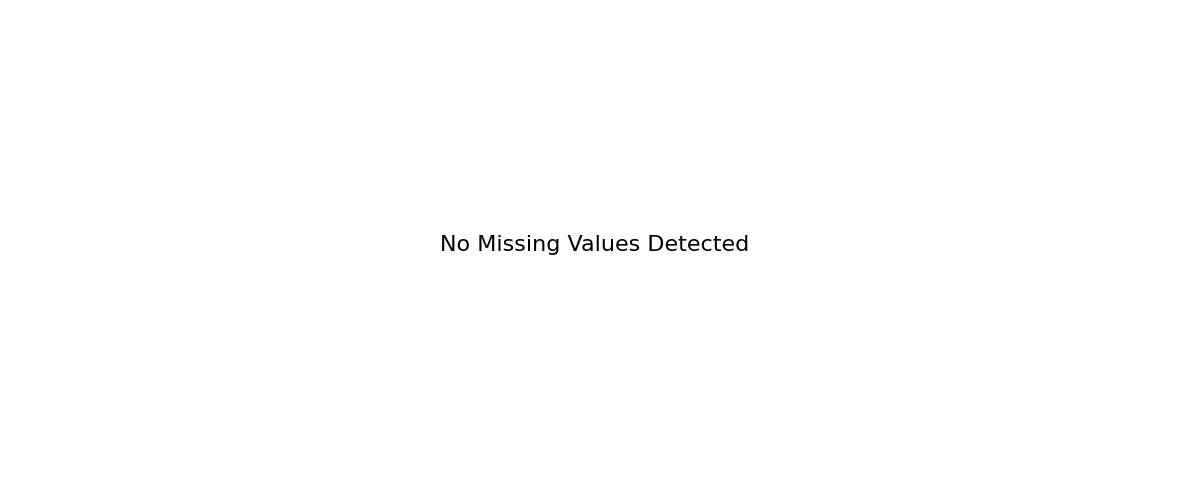

In [4]:


plt.figure(figsize=(12, 5))
missing_plot = df.isnull().sum()
missing_plot = missing_plot[missing_plot > 0]

if len(missing_plot) == 0:
    plt.text(0.5, 0.5, "No Missing Values Detected", ha="center", va="center", fontsize=16)
    plt.axis("off")
else:
    missing_plot.plot(kind="bar")
    plt.ylabel("Number of Missing Values")
    plt.title("Missing Value Analysis")
    plt.xticks(rotation=70)

plt.tight_layout()
plt.savefig(f"{FIG}/14_missing_value_analysis.png", dpi=300)
plt.show()




 5.OUTLIER DETECTION


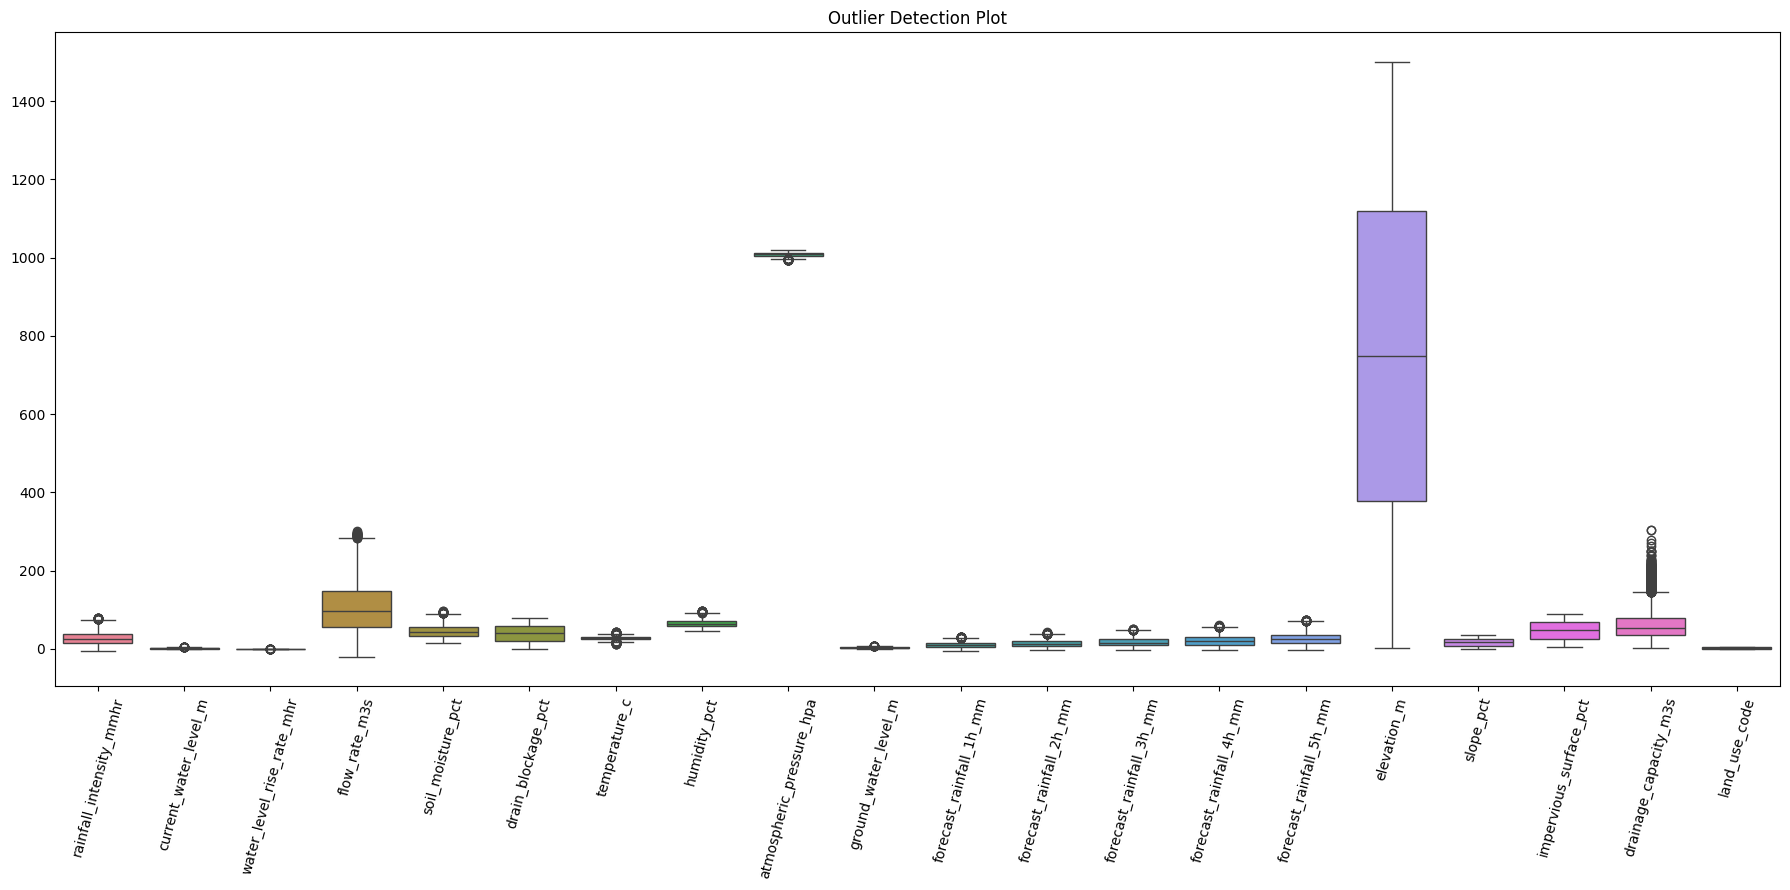

In [5]:

numeric_all = df.select_dtypes(include=np.number).columns.tolist()
numeric_features_all = [c for c in numeric_all if c != TARGET]

plt.figure(figsize=(18, 9))
sns.boxplot(data=df[numeric_features_all])
plt.xticks(rotation=75)
plt.title("Outlier Detection Plot")
plt.tight_layout()
plt.savefig(f"{FIG}/15_outlier_detection.png", dpi=300)
plt.show()



6. FEATURE DISTRIBUTIONS


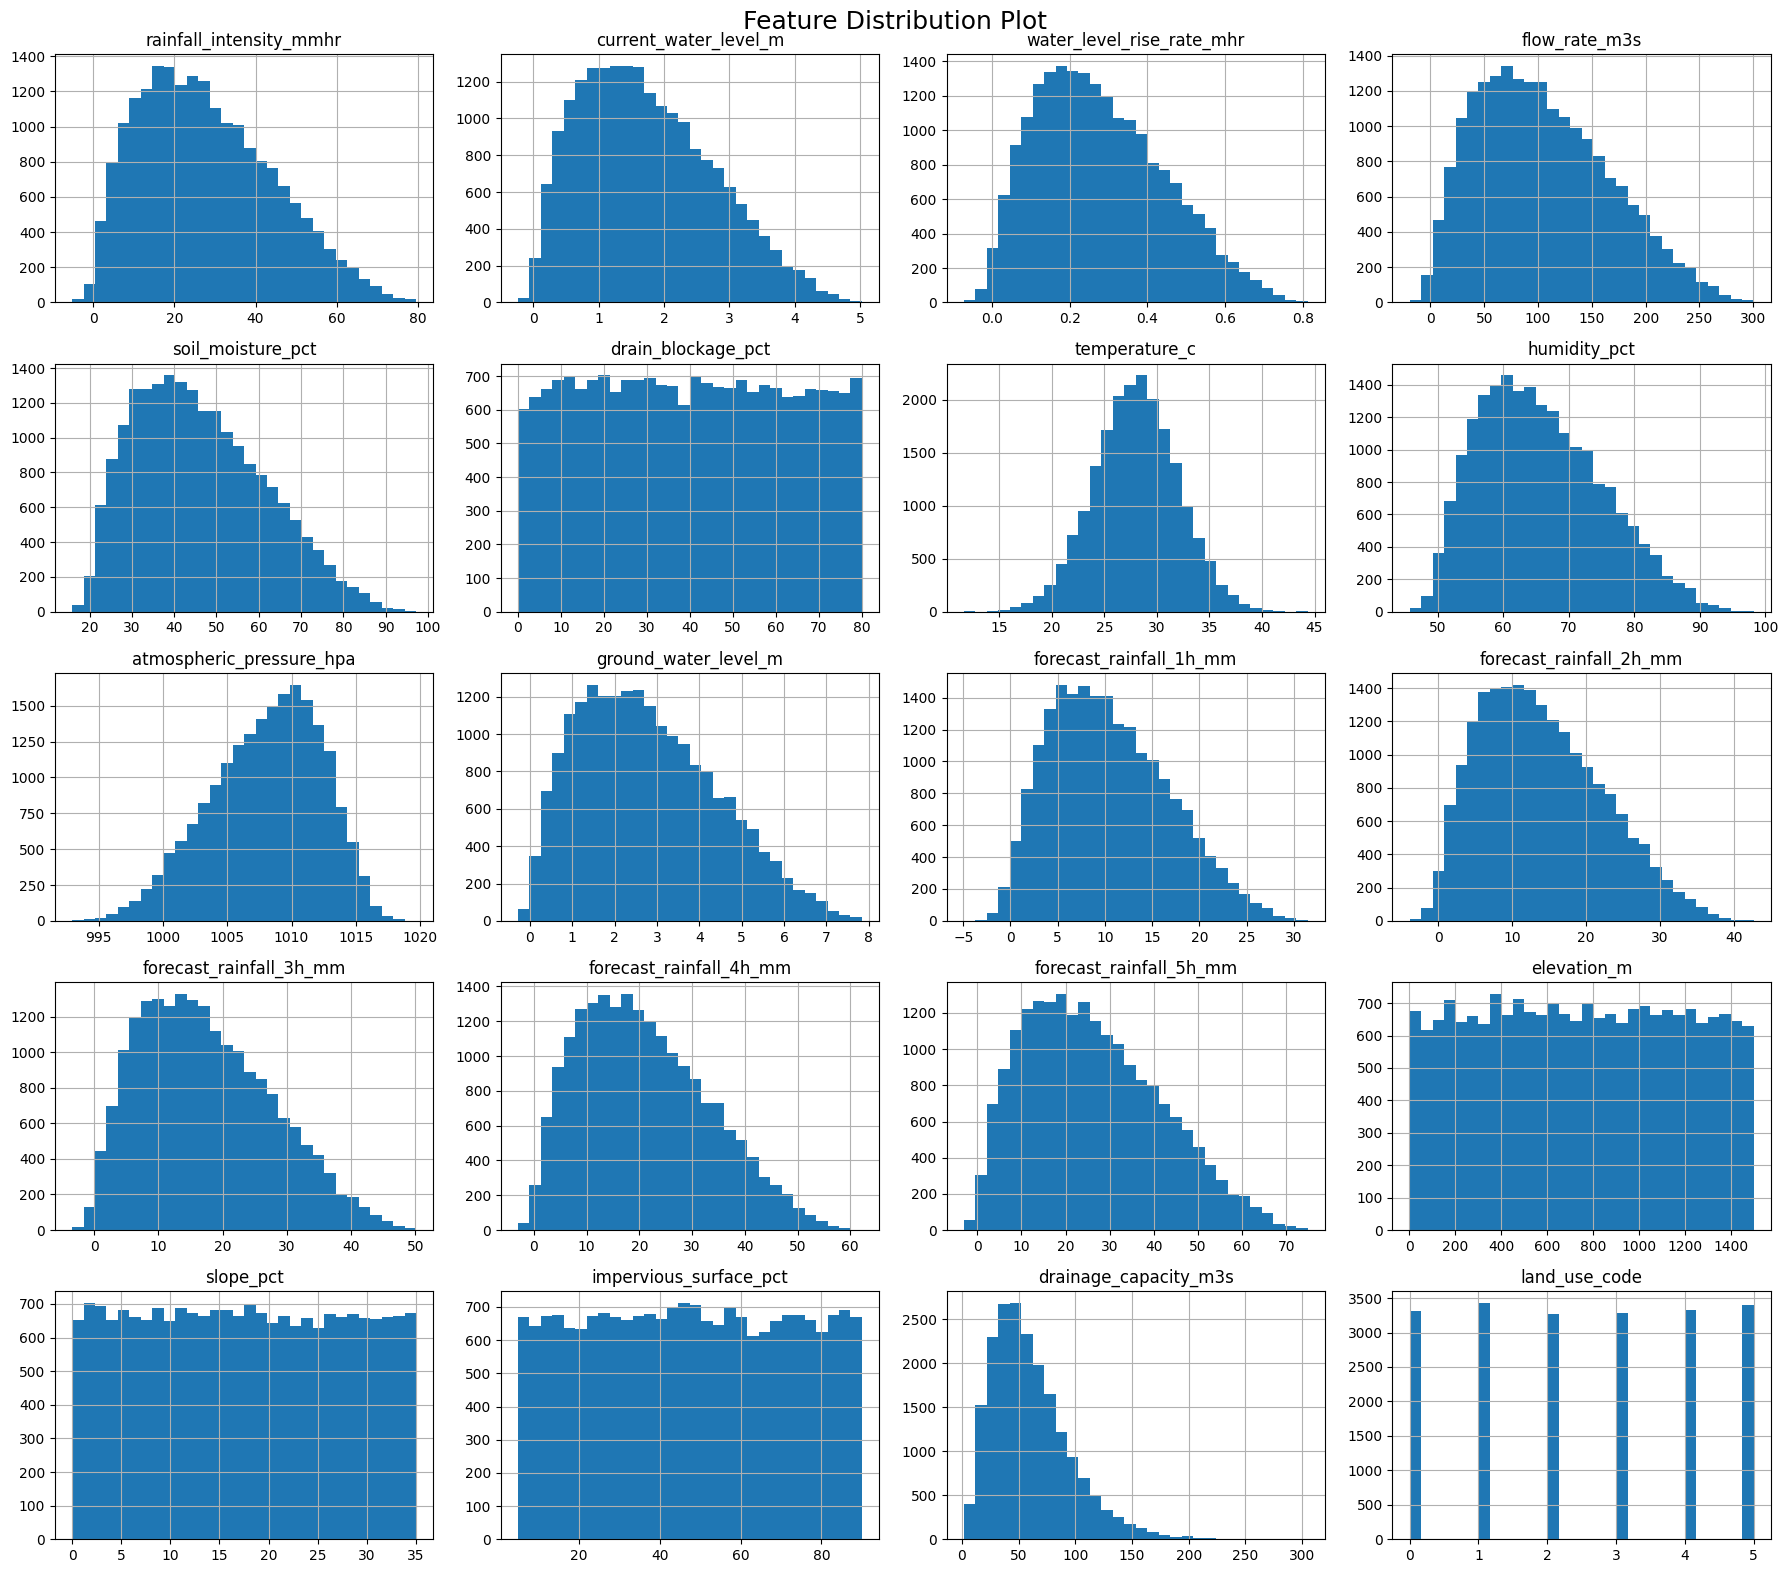

In [6]:

df[numeric_features_all].hist(figsize=(18, 16), bins=30)
plt.suptitle("Feature Distribution Plot", fontsize=18)
plt.tight_layout()
plt.savefig(f"{FIG}/16_feature_distribution.png", dpi=300)
plt.show()




7. CORRELATION HEATMAP (Black & Grey, annotated with values)


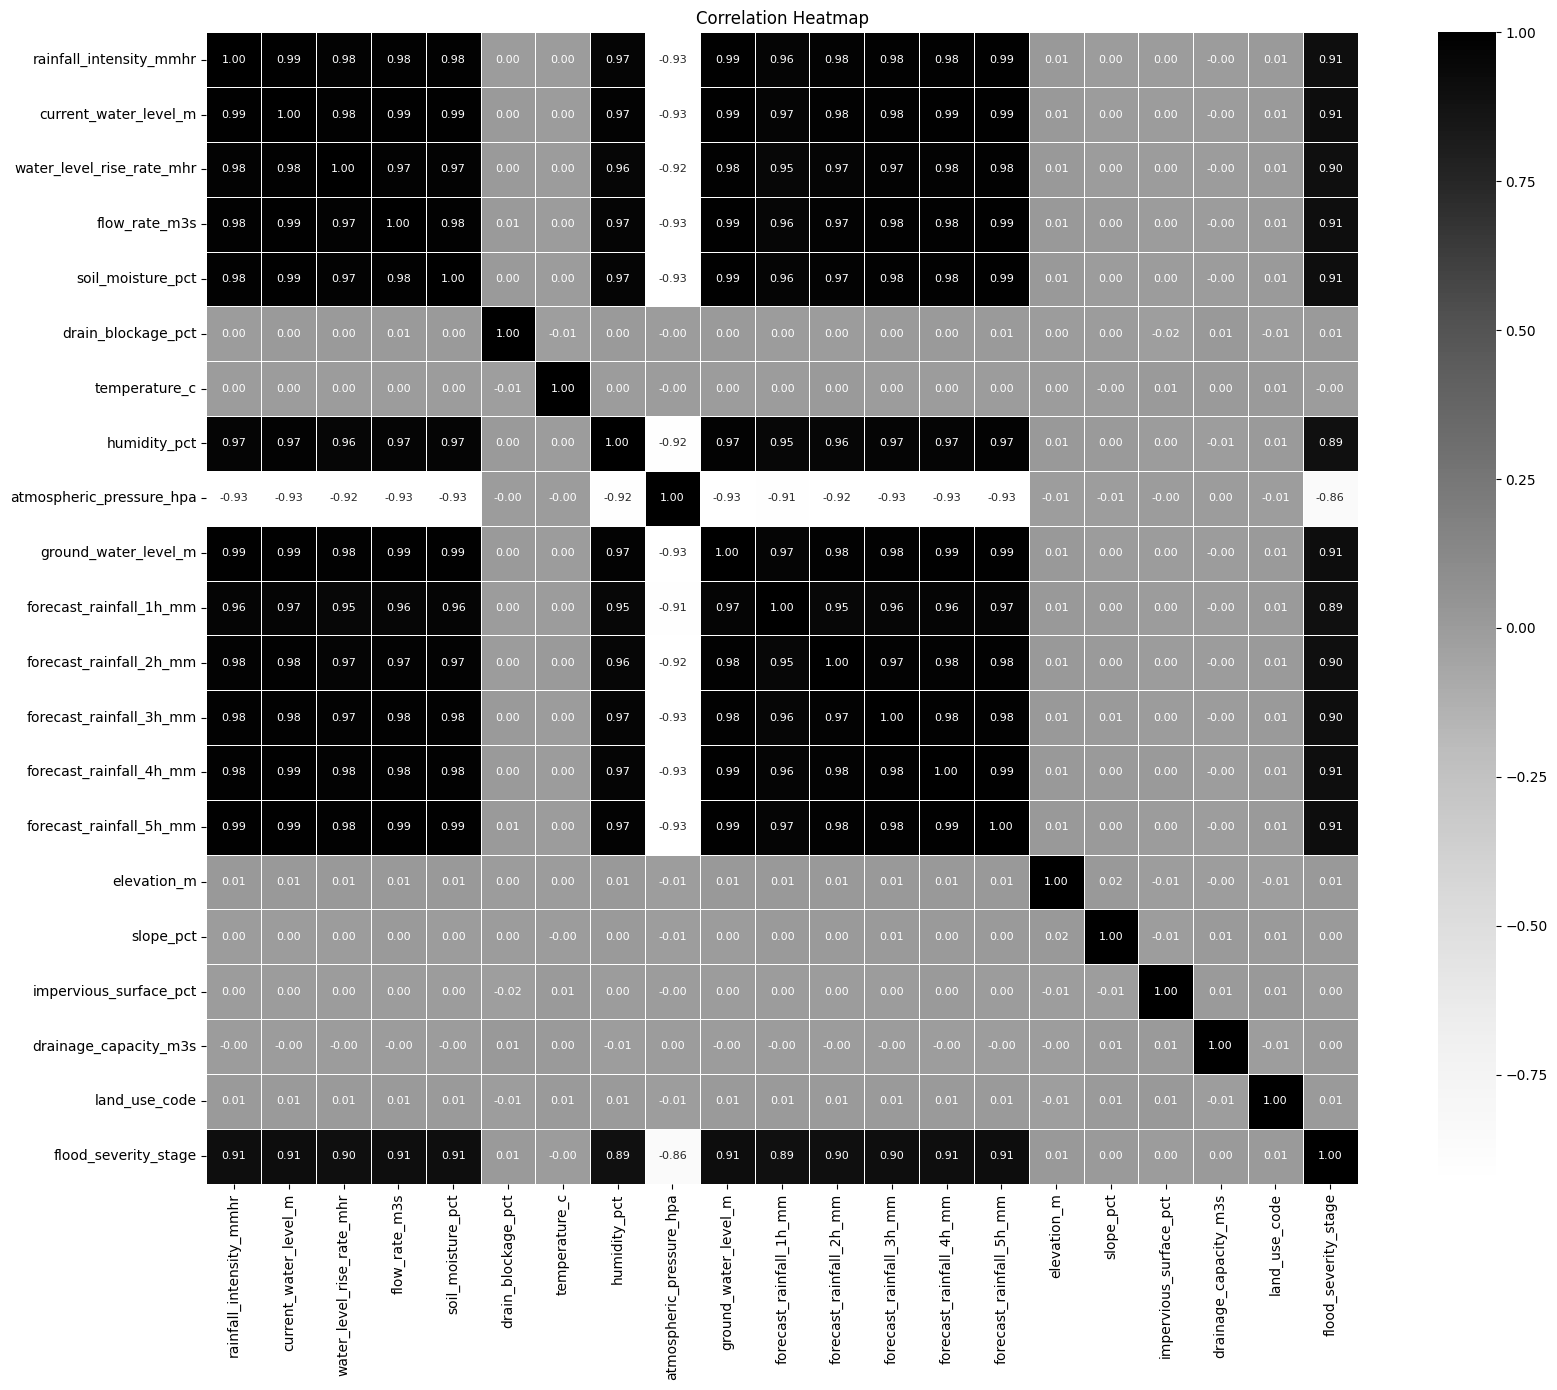

In [7]:

plt.figure(figsize=(18, 14))
corr = df[numeric_features_all + [TARGET]].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Greys",
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{FIG}/17_correlation_heatmap_black_grey.png", dpi=300, bbox_inches="tight")
plt.show()




## 8. TARGET DISTRIBUTION


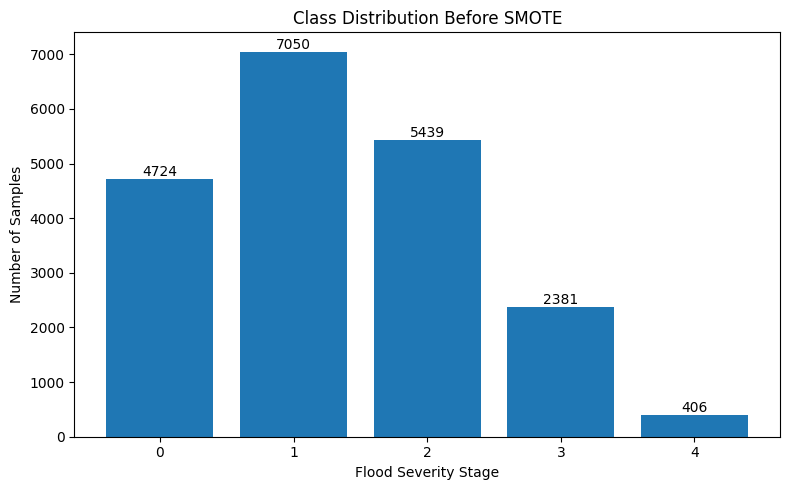

In [8]:

plt.figure(figsize=(8, 5))
counts = df[TARGET].value_counts().sort_index()

bars = plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Flood Severity Stage")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before SMOTE")

for b, v in zip(bars, counts.values):
    plt.text(b.get_x() + b.get_width()/2, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(f"{FIG}/20_class_distribution_before_smote.png", dpi=300)
plt.show()



## 9. DEFINE FEATURES


In [9]:

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("\nCategorical Features:", categorical_features)
print("Numeric Features:", numeric_features)





Categorical Features: ['land_use_name']
Numeric Features: ['rainfall_intensity_mmhr', 'current_water_level_m', 'water_level_rise_rate_mhr', 'flow_rate_m3s', 'soil_moisture_pct', 'drain_blockage_pct', 'temperature_c', 'humidity_pct', 'atmospheric_pressure_hpa', 'ground_water_level_m', 'forecast_rainfall_1h_mm', 'forecast_rainfall_2h_mm', 'forecast_rainfall_3h_mm', 'forecast_rainfall_4h_mm', 'forecast_rainfall_5h_mm', 'elevation_m', 'slope_pct', 'impervious_surface_pct', 'drainage_capacity_m3s', 'land_use_code']


## 10. TRAIN / TEST SPLIT


In [10]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("\nTraining Samples:", len(X_train_raw))
print("Testing Samples:", len(X_test_raw))





Training Samples: 16000
Testing Samples: 4000


## 11. PREPROCESSING


In [11]:

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

X_train_pre = preprocessor.fit_transform(X_train_raw)
X_test_pre = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_pre = pd.DataFrame(X_train_pre, columns=feature_names, index=X_train_raw.index)
X_test_pre = pd.DataFrame(X_test_pre, columns=feature_names, index=X_test_raw.index)

print("\nPreprocessed Feature Count:", X_train_pre.shape[1])





Preprocessed Feature Count: 26


## 12 FEATURE SELECTION


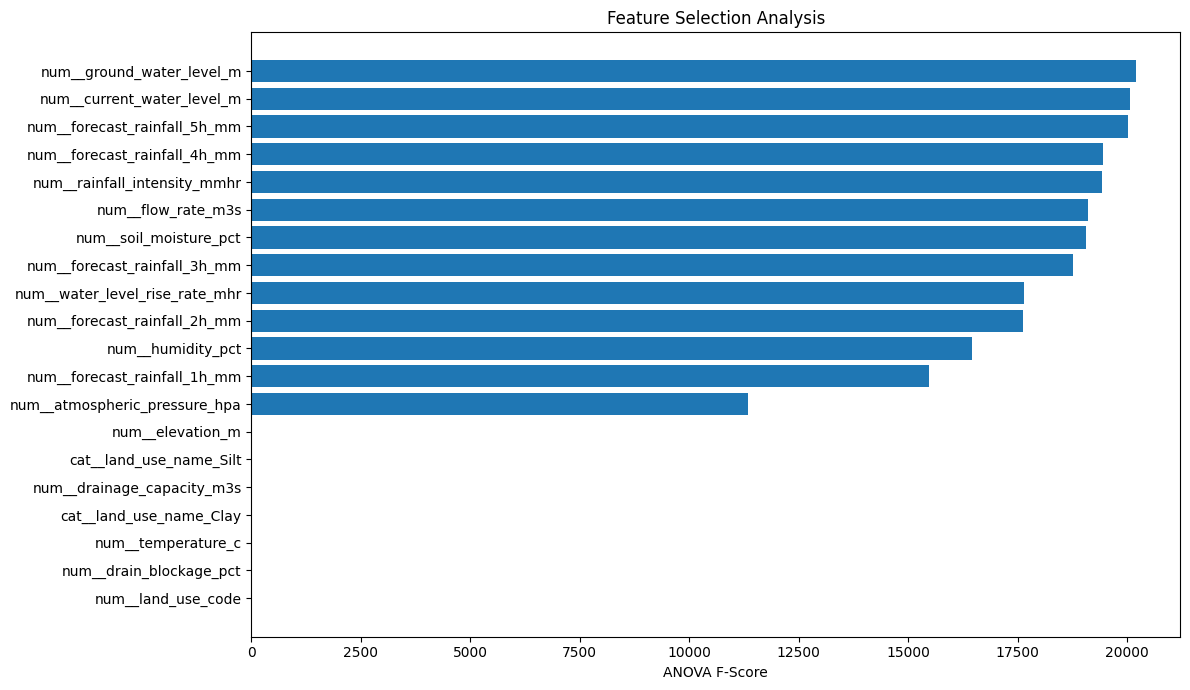


Selected Features:
['num__rainfall_intensity_mmhr' 'num__current_water_level_m'
 'num__water_level_rise_rate_mhr' 'num__flow_rate_m3s'
 'num__soil_moisture_pct' 'num__temperature_c' 'num__humidity_pct'
 'num__atmospheric_pressure_hpa' 'num__ground_water_level_m'
 'num__forecast_rainfall_1h_mm' 'num__forecast_rainfall_2h_mm'
 'num__forecast_rainfall_3h_mm' 'num__forecast_rainfall_4h_mm'
 'num__forecast_rainfall_5h_mm' 'num__elevation_m'
 'num__drainage_capacity_m3s' 'cat__land_use_name_Clay'
 'cat__land_use_name_Silt']


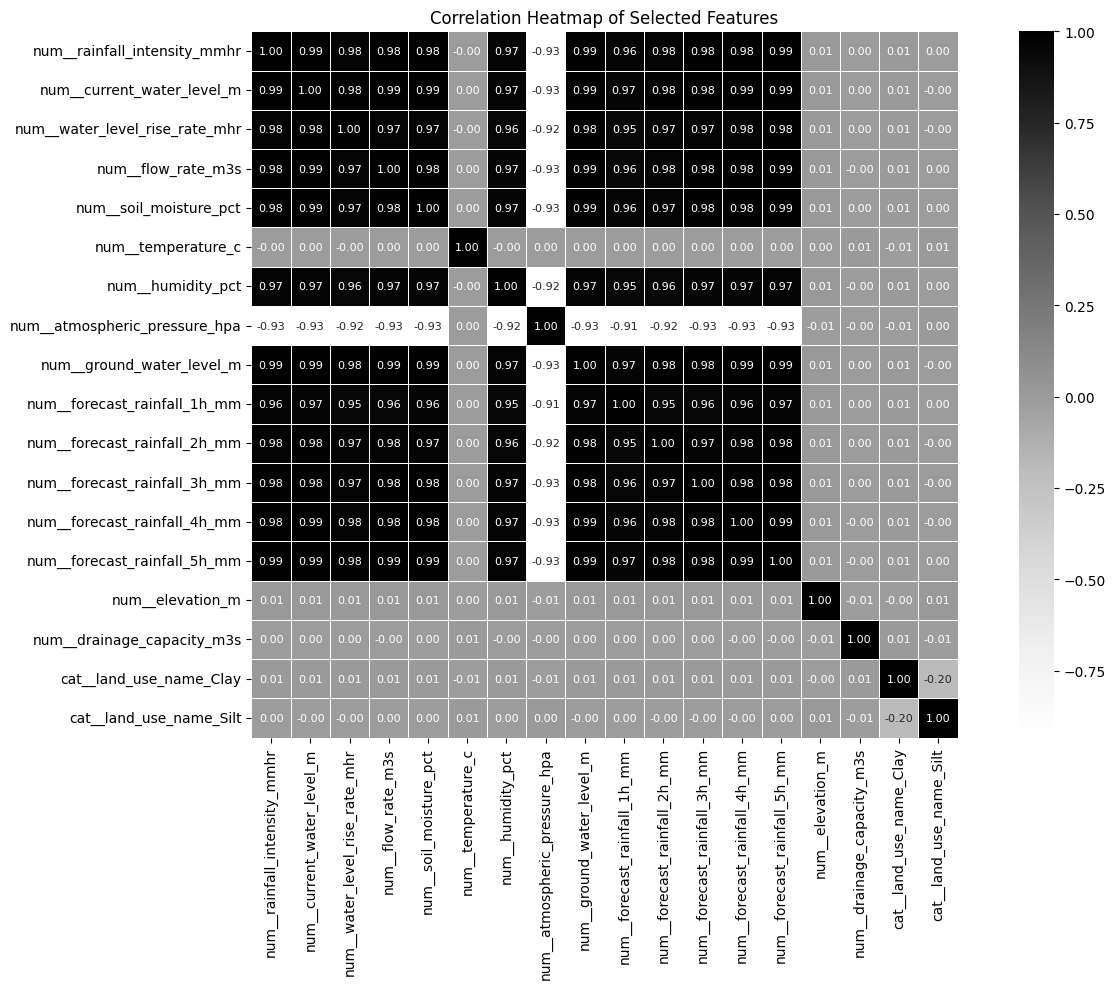

In [12]:

k = min(18, X_train_pre.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)

X_train_sel = selector.fit_transform(X_train_pre, y_train)
X_test_sel = selector.transform(X_test_pre)

selected_features = feature_names[selector.get_support()]

feature_scores = pd.DataFrame({
    "Feature": feature_names,
    "F_Score": selector.scores_,
    "Selected": selector.get_support()
}).sort_values("F_Score", ascending=False)

feature_scores.to_csv(f"{TAB}/feature_selection_scores.csv", index=False)

plt.figure(figsize=(12, 7))
top_scores = feature_scores.head(20).sort_values("F_Score")
plt.barh(top_scores["Feature"], top_scores["F_Score"])
plt.xlabel("ANOVA F-Score")
plt.title("Feature Selection Analysis")
plt.tight_layout()
plt.savefig(f"{FIG}/18_feature_selection_analysis.png", dpi=300)
plt.show()

print("\nSelected Features:")
print(selected_features)

# =========================
# 12b. CORRELATION HEATMAP OF SELECTED FEATURES ONLY (Black & Grey, annotated)
# =========================
selected_df = X_train_pre[selected_features]
corr_selected = selected_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_selected,
    annot=True,
    fmt=".2f",
    cmap="Greys",
    linewidths=0.5,
    square=True,
    cbar=True,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap of Selected Features")
plt.tight_layout()
plt.savefig(f"{FIG}/18_selected_features_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()




## 13. PCA


In [13]:

pca_full = PCA()
pca_full.fit(X_train_sel)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca = pca.transform(X_test_sel)

print("\nPCA Components for 95% Variance:", n_components)





PCA Components for 95% Variance: 4


## 19. PCA EXPLAINED VARIANCE


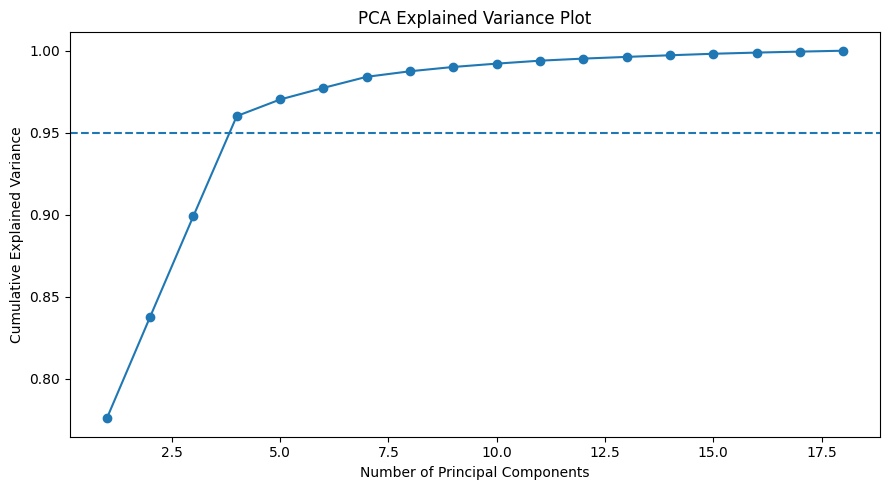

In [14]:

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Plot")
plt.tight_layout()
plt.savefig(f"{FIG}/19_pca_explained_variance.png", dpi=300)
plt.show()



## 14. SMOTE


In [15]:

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

print("\nClass Distribution Before SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())





Class Distribution Before SMOTE:
flood_severity_stage
0    3779
1    5640
2    4351
3    1905
4     325
Name: count, dtype: int64

Class Distribution After SMOTE:
flood_severity_stage
0    5640
1    5640
2    5640
3    5640
4    5640
Name: count, dtype: int64


## 20. CLASS DISTRIBUTION BEFORE / AFTER SMOTE


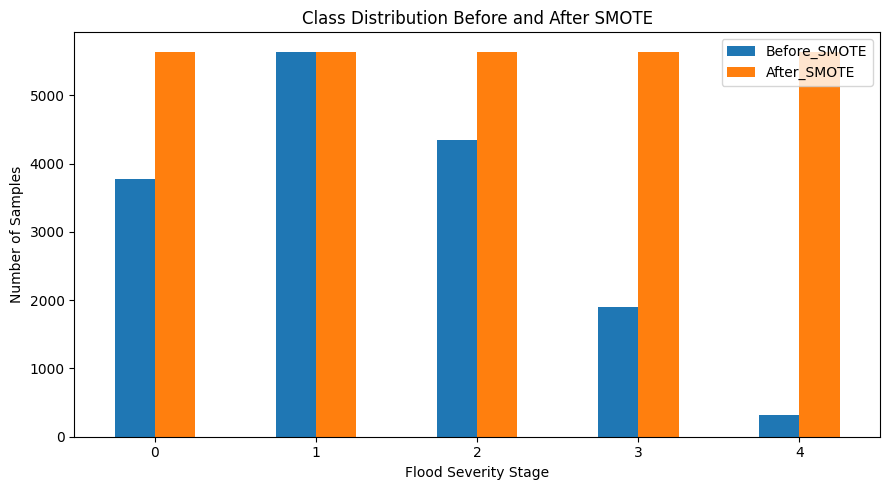

In [16]:

before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_smote).value_counts().sort_index()

dist_df = pd.DataFrame({"Before_SMOTE": before, "After_SMOTE": after})
dist_df.to_csv(f"{TAB}/class_distribution_smote.csv")

dist_df.plot(kind="bar", figsize=(9, 5))
plt.xlabel("Flood Severity Stage")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After SMOTE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG}/20_class_distribution_before_after_smote.png", dpi=300)
plt.show()




## 21. PCA VISUALIZATION BEFORE / AFTER SMOTE


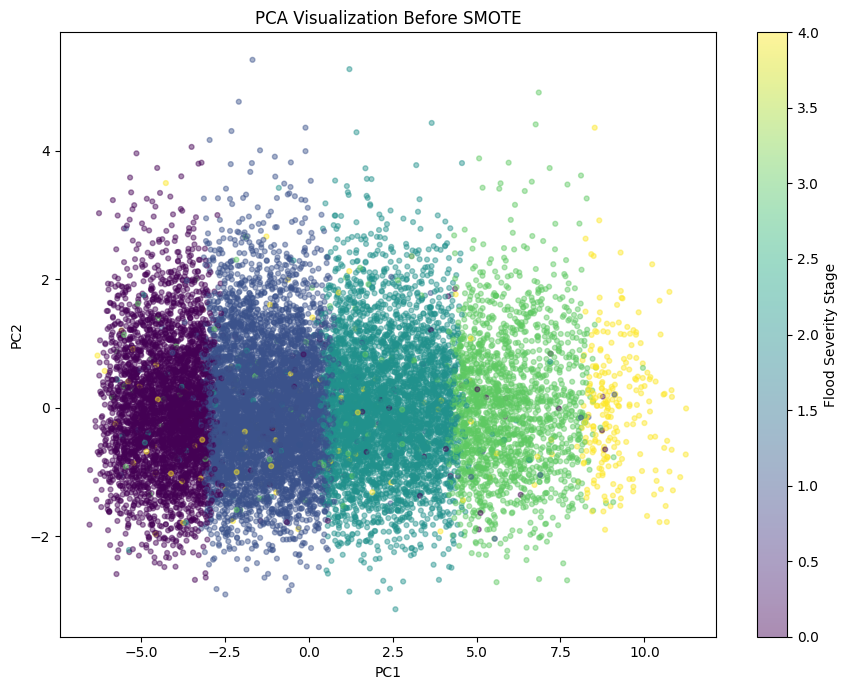

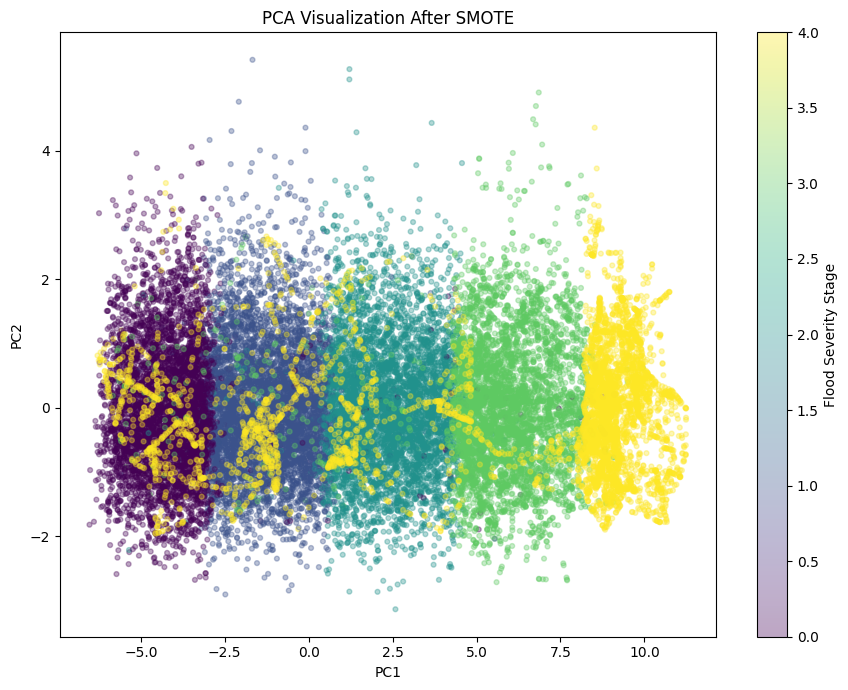

In [17]:

if X_train_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 7))
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, alpha=0.45, s=12)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Visualization Before SMOTE")
    plt.colorbar(label="Flood Severity Stage")
    plt.tight_layout()
    plt.savefig(f"{FIG}/49_pca_before_smote.png", dpi=300)
    plt.show()

    plt.figure(figsize=(9, 7))
    plt.scatter(X_train_smote[:, 0], X_train_smote[:, 1], c=y_train_smote, alpha=0.35, s=12)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA Visualization After SMOTE")
    plt.colorbar(label="Flood Severity Stage")
    plt.tight_layout()
    plt.savefig(f"{FIG}/49_pca_after_smote.png", dpi=300)
    plt.show()

# classes needed by the metrics/eval section below
classes = np.sort(np.unique(y_test))

# ================================================================
# FAST HYPERPARAMETER TUNING STAGE
# 3 candidates x 3 folds = 9 fits/model (instead of 15 x 5 = 75)
# FIXED: uses GridSearchCV over the exact 3 candidate configs per model,
# since these are fixed configurations, not distributions to sample from.
# ================================================================

required_variables = [
    "X_train_smote", "y_train_smote", "X_test_pca", "y_test", "X_train_pca", "classes"
]
missing_variables = [v for v in required_variables if v not in globals()]
if missing_variables:
    raise RuntimeError(
        "Run the preprocessing + SMOTE cells first. "
        f"Missing variables: {missing_variables}"
    )

# ================================================================
# FAST CROSS-VALIDATION
# ================================================================
cv_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)




## 22. FAST MODEL DEFINITIONS


In [18]:

models = {
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train_smote)),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "SVM-RBF": SVC(
        kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        max_iter=250, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=10, random_state=RANDOM_STATE
    ),
    "ExtraTrees": ExtraTreesClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced"
    )
}



## 23. SMALL HYPERPARAMETER SEARCH SPACE (exactly 3 fixed candidates per model)


In [19]:
# SMALL HYPERPARAMETER SEARCH SPACE (exactly 3 fixed candidates per model)
# Each value is wrapped in a single-element list so GridSearchCV can
# consume it directly as a param_grid entry.

param_distributions = {
    "XGBoost": [
        {"n_estimators": [200], "max_depth": [3], "learning_rate": [0.05], "subsample": [0.8], "colsample_bytree": [0.8]},
        {"n_estimators": [300], "max_depth": [5], "learning_rate": [0.05], "subsample": [0.9], "colsample_bytree": [0.8]},
        {"n_estimators": [250], "max_depth": [6], "learning_rate": [0.10], "subsample": [0.8], "colsample_bytree": [0.9]}
    ],
    "SVM-RBF": [
        {"C": [1], "gamma": ["scale"]},
        {"C": [5], "gamma": ["scale"]},
        {"C": [10], "gamma": [0.01]}
    ],
    "MLP": [
        {"hidden_layer_sizes": [(64,)], "activation": ["relu"], "alpha": [0.001], "learning_rate_init": [0.001]},
        {"hidden_layer_sizes": [(128, 64)], "activation": ["relu"], "alpha": [0.0001], "learning_rate_init": [0.001]},
        {"hidden_layer_sizes": [(128, 64, 32)], "activation": ["relu"], "alpha": [0.001], "learning_rate_init": [0.0005]}
    ],
    "ExtraTrees": [
        {"n_estimators": [200], "max_depth": [None], "min_samples_split": [2], "min_samples_leaf": [1], "max_features": ["sqrt"]},
        {"n_estimators": [300], "max_depth": [15], "min_samples_split": [4], "min_samples_leaf": [2], "max_features": ["sqrt"]},
        {"n_estimators": [250], "max_depth": [20], "min_samples_split": [5], "min_samples_leaf": [2], "max_features": ["log2"]}
    ]
}


## 24. FAST HYPERPARAMETER TUNING (9 fits/model: 3 candidates x 3 folds)


In [20]:
#  FAST HYPERPARAMETER TUNING (9 fits/model: 3 candidates x 3 folds)
# GridSearchCV evaluates each of the 3 fixed candidate configs exactly once
# per fold (3 folds), giving the intended 9 fits/model with no randomness
# in which candidates get tried.

best_models = {}
tuning_results = []

for name, model in models.items():
    print("\n" + "=" * 70)
    print("FAST TUNING:", name)
    print("=" * 70)

    search = GridSearchCV(
        estimator=model,
        param_grid=param_distributions[name],
        scoring="f1_macro",
        cv=cv_fast,         # 3 folds x 3 candidates = 9 fits
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train_smote, y_train_smote)

    best_models[name] = search.best_estimator_

    tuning_results.append({
        "Model": name,
        "Best_CV_Macro_F1": search.best_score_,
        "Best_Parameters": str(search.best_params_)
    })

    print(f"\n{name} Best Macro-F1: {search.best_score_:.4f}")
    print("Best Parameters:", search.best_params_)




FAST TUNING: XGBoost
Fitting 3 folds for each of 3 candidates, totalling 9 fits

XGBoost Best Macro-F1: 0.9243
Best Parameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250, 'subsample': 0.8}

FAST TUNING: SVM-RBF
Fitting 3 folds for each of 3 candidates, totalling 9 fits

SVM-RBF Best Macro-F1: 0.8963
Best Parameters: {'C': 5, 'gamma': 'scale'}

FAST TUNING: MLP
Fitting 3 folds for each of 3 candidates, totalling 9 fits

MLP Best Macro-F1: 0.8946
Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

FAST TUNING: ExtraTrees
Fitting 3 folds for each of 3 candidates, totalling 9 fits

ExtraTrees Best Macro-F1: 0.9418
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


## 25. SAVE TUNING RESULTS


In [22]:

tuning_df = pd.DataFrame(tuning_results)
tuning_df.to_csv(f"{TAB}/fast_hyperparameter_tuning_results.csv", index=False)
display(tuning_df)


,Model,Best_CV_Macro_F1,Best_Parameters
0,XGBoost,0.924277,"{'colsample_bytree': 0.9, 'learning_rate': 0.1..."
1,SVM-RBF,0.896282,"{'C': 5, 'gamma': 'scale'}"
2,MLP,0.894638,"{'activation': 'relu', 'alpha': 0.0001, 'hidde..."
3,ExtraTrees,0.941825,"{'max_depth': None, 'max_features': 'sqrt', 'm..."


## 26. HYPERPARAMETER TUNING FIGURE


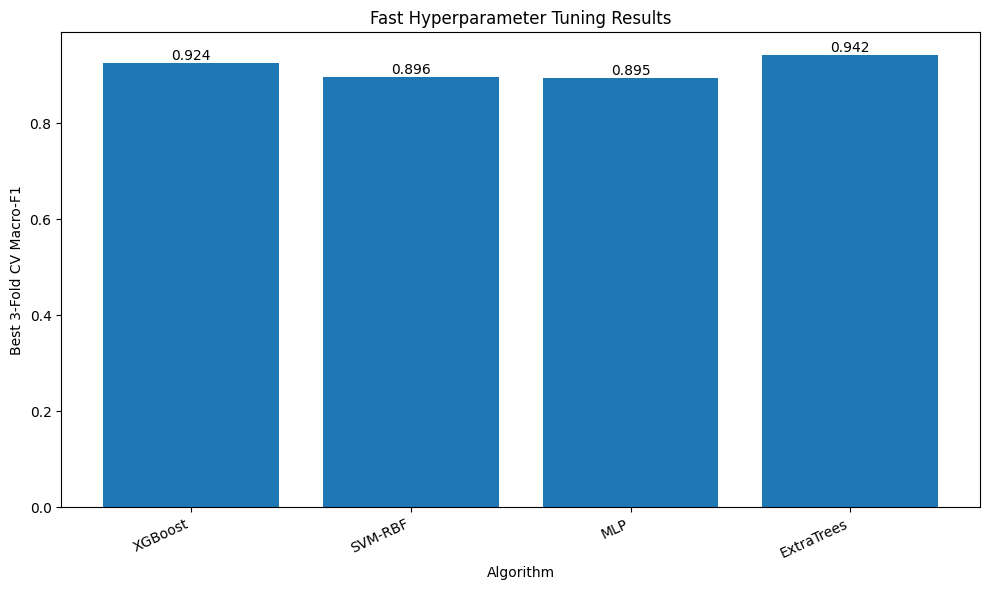

In [23]:

plt.figure(figsize=(10, 6))
bars = plt.bar(tuning_df["Model"], tuning_df["Best_CV_Macro_F1"])
plt.ylabel("Best 3-Fold CV Macro-F1")
plt.xlabel("Algorithm")
plt.title("Fast Hyperparameter Tuning Results")
plt.xticks(rotation=25, ha="right")
for bar, value in zip(bars, tuning_df["Best_CV_Macro_F1"]):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG}/23_fast_hyperparameter_tuning_results.png", dpi=300)
plt.show()




## 27. TRAIN TUNED CLASSICAL MODELS


In [24]:

print("\n" + "=" * 70)
print("TRAINING FINAL TUNED CLASSICAL MODELS")
print("=" * 70)

for name, model in best_models.items():
    print(f"Training {name}...")
    model.fit(X_train_smote, y_train_smote)
    print(f"{name} completed.")





TRAINING FINAL TUNED CLASSICAL MODELS
Training XGBoost...
XGBoost completed.
Training SVM-RBF...
SVM-RBF completed.
Training MLP...
MLP completed.
Training ExtraTrees...
ExtraTrees completed.


## 28. TABNET


In [25]:

print("\n" + "=" * 70)
print("TRAINING TABNET")
print("=" * 70)

tabnet_model = TabNetClassifier(
    n_d=16, n_a=16, n_steps=4, gamma=1.3, lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam, optimizer_params={"lr": 0.01},
    mask_type="entmax", seed=RANDOM_STATE, verbose=0
)

tabnet_model.fit(
    X_train_smote.astype(np.float32),
    np.asarray(y_train_smote),
    eval_set=[(X_test_pca.astype(np.float32), np.asarray(y_test))],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=60,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128
)

best_models["TabNet"] = tabnet_model
print("TabNet completed.")





TRAINING TABNET

Early stopping occurred at epoch 37 with best_epoch = 27 and best_test_accuracy = 0.936
TabNet completed.


## 29. FT-TRANSFORMER


In [26]:

class FTTransformer(nn.Module):
    def __init__(self, n_features, n_classes, d_token=48, n_heads=4, n_layers=2, dropout=0.20):
        super().__init__()
        self.feature_embedding = nn.Linear(1, d_token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        self.position_embedding = nn.Parameter(torch.randn(1, n_features + 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token * 2,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)
        self.head = nn.Sequential(
            nn.Linear(d_token, 48), nn.GELU(), nn.Dropout(dropout), nn.Linear(48, n_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.feature_embedding(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.position_embedding[:, :x.size(1)]
        x = self.encoder(x)
        x = self.norm(x[:, 0])
        return self.head(x)


def train_torch_model(model, Xtr, ytr, Xval, yval, epochs=50, lr=0.001, batch_size=512, patience=8):
    model = model.to(device)
    Xtr_tensor = torch.tensor(Xtr, dtype=torch.float32)
    ytr_tensor = torch.tensor(np.asarray(ytr), dtype=torch.long)
    Xval_tensor = torch.tensor(Xval, dtype=torch.float32).to(device)
    yval_tensor = torch.tensor(np.asarray(yval), dtype=torch.long).to(device)

    loader = DataLoader(TensorDataset(Xtr_tensor, ytr_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    best_loss = np.inf
    best_state = None
    wait = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(Xval_tensor)
            val_loss = criterion(val_logits, yval_tensor).item()

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


print("\n" + "=" * 70)
print("TRAINING FT-TRANSFORMER")
print("=" * 70)

ft_model = FTTransformer(
    n_features=X_train_smote.shape[1], n_classes=len(np.unique(y_train_smote)),
    d_token=48, n_heads=4, n_layers=2, dropout=0.20
)

ft_model = train_torch_model(
    ft_model, X_train_smote, y_train_smote, X_test_pca, y_test,
    epochs=50, lr=0.001, batch_size=512, patience=8
)

best_models["FT-Transformer"] = ft_model
print("FT-Transformer completed.")



TRAINING FT-TRANSFORMER
FT-Transformer completed.


## 30. SAINT


In [27]:

class SAINT(nn.Module):
    def __init__(self, n_features, n_classes, d_token=48, n_heads=4, n_layers=2, dropout=0.25):
        super().__init__()
        self.embedding = nn.Linear(1, d_token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        self.pos = nn.Parameter(torch.randn(1, n_features + 1, d_token))
        layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token * 2,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_token), nn.Linear(d_token, 48), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(48, n_classes)
        )

    def forward(self, x):
        x = self.embedding(x.unsqueeze(-1))
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos[:, :x.size(1)]
        x = self.encoder(x)
        return self.head(x[:, 0])


print("\n" + "=" * 70)
print("TRAINING SAINT")
print("=" * 70)

saint_model = SAINT(
    n_features=X_train_smote.shape[1], n_classes=len(np.unique(y_train_smote)),
    d_token=48, n_heads=4, n_layers=2, dropout=0.25
)

saint_model = train_torch_model(
    saint_model, X_train_smote, y_train_smote, X_test_pca, y_test,
    epochs=50, lr=0.0008, batch_size=512, patience=8
)

best_models["SAINT"] = saint_model
print("SAINT completed.")




TRAINING SAINT
SAINT completed.


## 31. PREDICTION FUNCTION


In [28]:

def get_predictions(model, name, Xdata):
    if name == "TabNet":
        proba = model.predict_proba(Xdata.astype(np.float32))
        pred = np.argmax(proba, axis=1)
        return pred, proba
    elif name in ["FT-Transformer", "SAINT"]:
        model.eval()
        with torch.no_grad():
            xt = torch.tensor(Xdata, dtype=torch.float32).to(device)
            logits = model(xt)
            proba = torch.softmax(logits, dim=1).cpu().numpy()
        pred = np.argmax(proba, axis=1)
        return pred, proba
    else:
        pred = model.predict(Xdata)
        proba = model.predict_proba(Xdata)
        return pred, proba


## 32. METRIC FUNCTION


In [29]:

def calculate_metrics(y_true, y_pred, y_prob, name):
    cm = confusion_matrix(y_true, y_pred)
    sensitivity_values, specificity_values = [], []

    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sensitivity = tp / (tp + fn) if tp + fn > 0 else 0
        specificity = tn / (tn + fp) if tn + fp > 0 else 0
        sensitivity_values.append(sensitivity)
        specificity_values.append(specificity)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Sensitivity": np.mean(sensitivity_values),
        "Specificity": np.mean(specificity_values),
        "ROC-AUC": roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    }



## 33. FINAL EVALUATION


In [30]:

print("\n" + "=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

results = []
predictions = {}
probabilities = {}

for name, model in best_models.items():
    print("Evaluating:", name)
    pred, prob = get_predictions(model, name, X_test_pca)
    predictions[name] = pred
    probabilities[name] = prob
    result = calculate_metrics(y_test, pred, prob, name)
    results.append(result)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df.to_csv(f"{TAB}/final_model_performance.csv", index=False)

print("\nFINAL RESULTS")
display(results_df.style.format({c: "{:.4f}" for c in results_df.columns if c != "Model"}))





FINAL MODEL EVALUATION
Evaluating: XGBoost
Evaluating: SVM-RBF
Evaluating: MLP
Evaluating: ExtraTrees
Evaluating: TabNet
Evaluating: FT-Transformer
Evaluating: SAINT

FINAL RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,MCC,Sensitivity,Specificity,ROC-AUC
0,SAINT,0.9410,0.9424,0.8883,0.9108,0.8883,0.9192,0.8883,0.9836,0.9470
1,FT-Transformer,0.9393,0.9407,0.8847,0.9067,0.8847,0.9168,0.8847,0.9833,0.9486
2,SVM-RBF,0.9385,0.9237,0.8912,0.9053,0.8912,0.9158,0.8912,0.9832,0.9517
3,TabNet,0.9360,0.9020,0.8878,0.8942,0.8878,0.9125,0.8878,0.9827,0.9525
4,ExtraTrees,0.9347,0.8888,0.8856,0.8871,0.8856,0.9108,0.8856,0.9823,0.9604
5,XGBoost,0.9305,0.8722,0.8853,0.8783,0.8853,0.9051,0.8853,0.9814,0.9541
6,MLP,0.9285,0.8636,0.8855,0.8737,0.8855,0.9025,0.8855,0.9811,0.9537


## 34. METRIC FIGURES


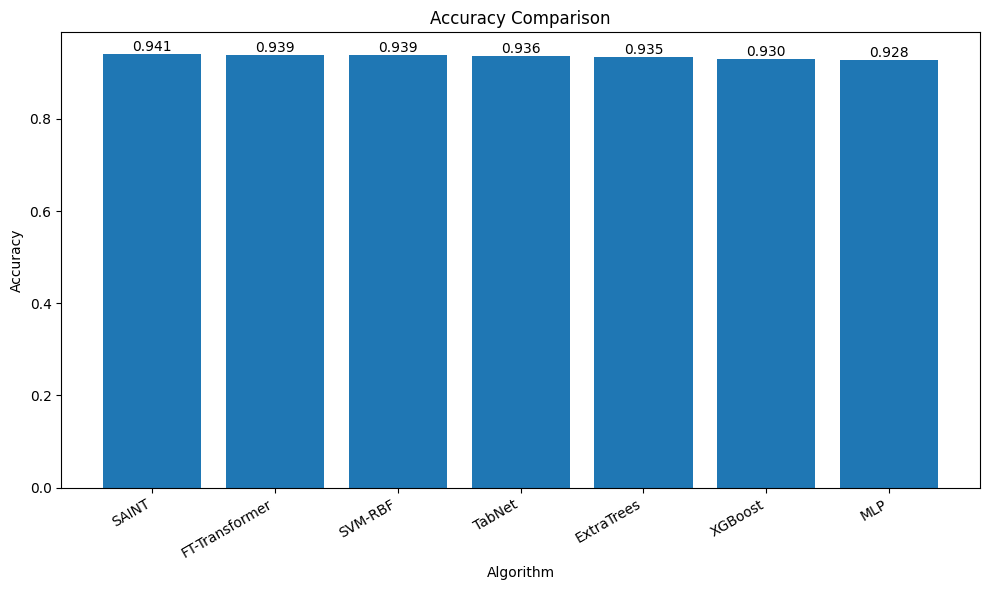

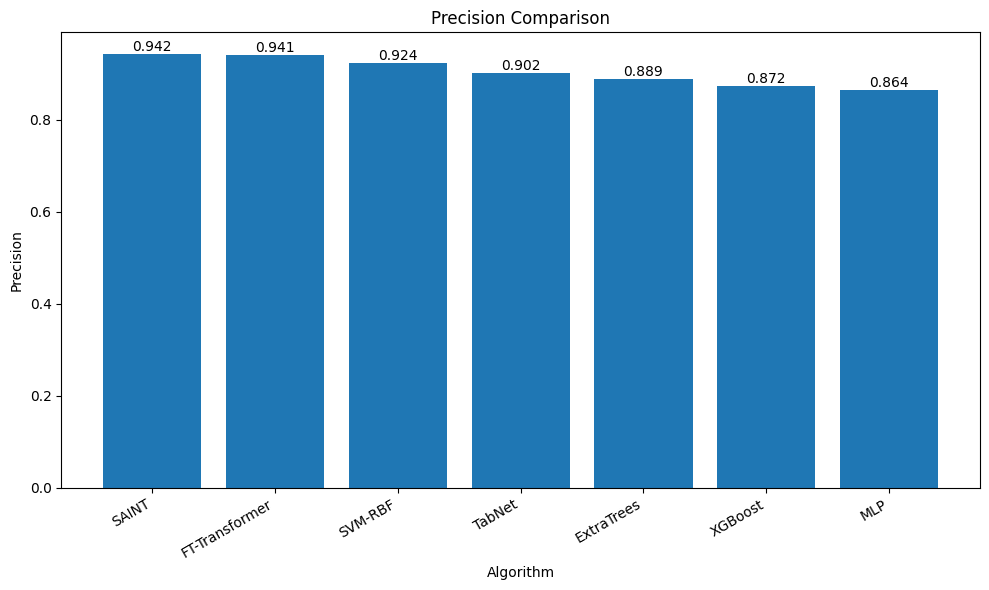

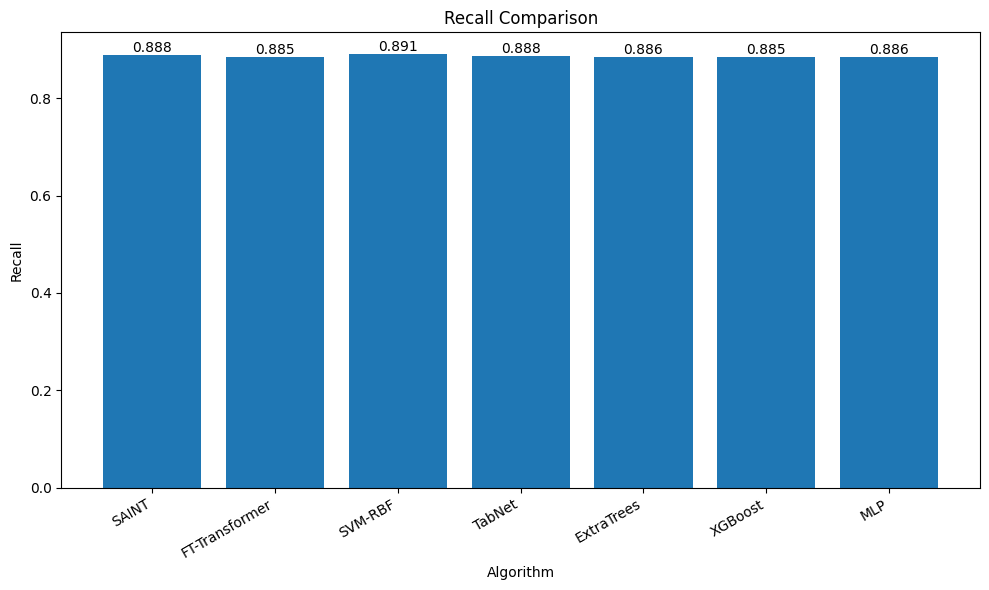

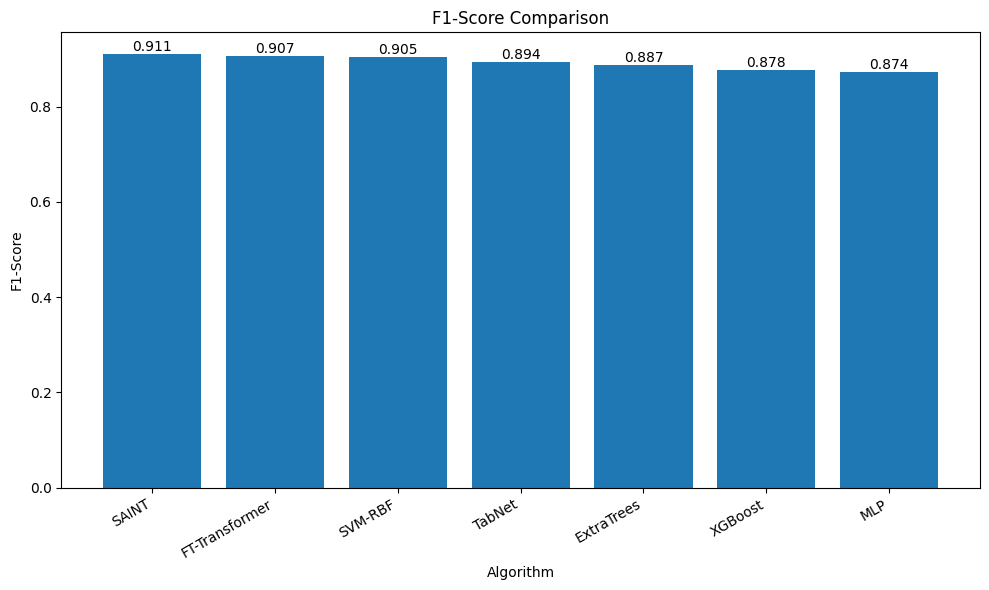

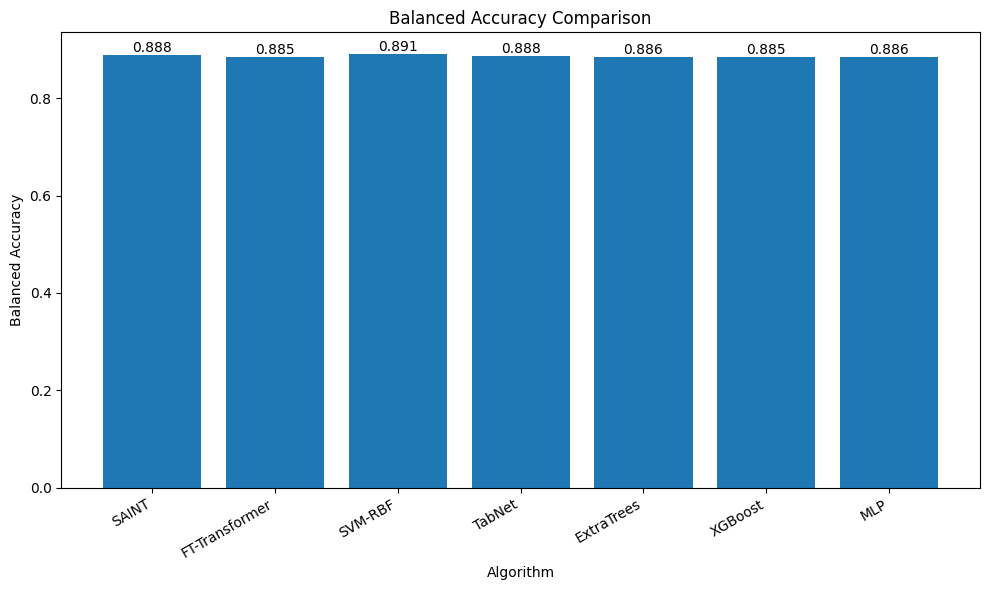

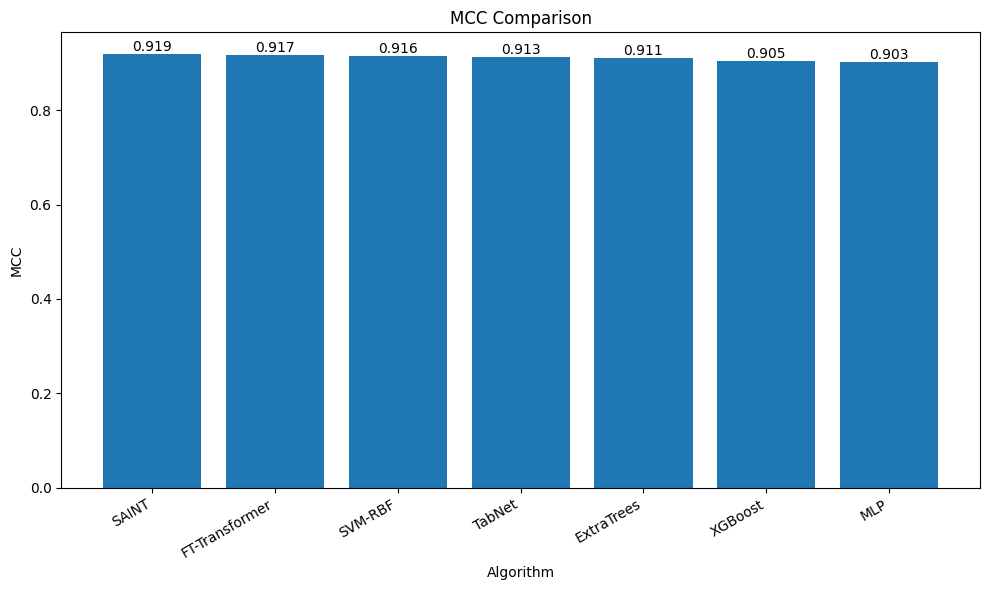

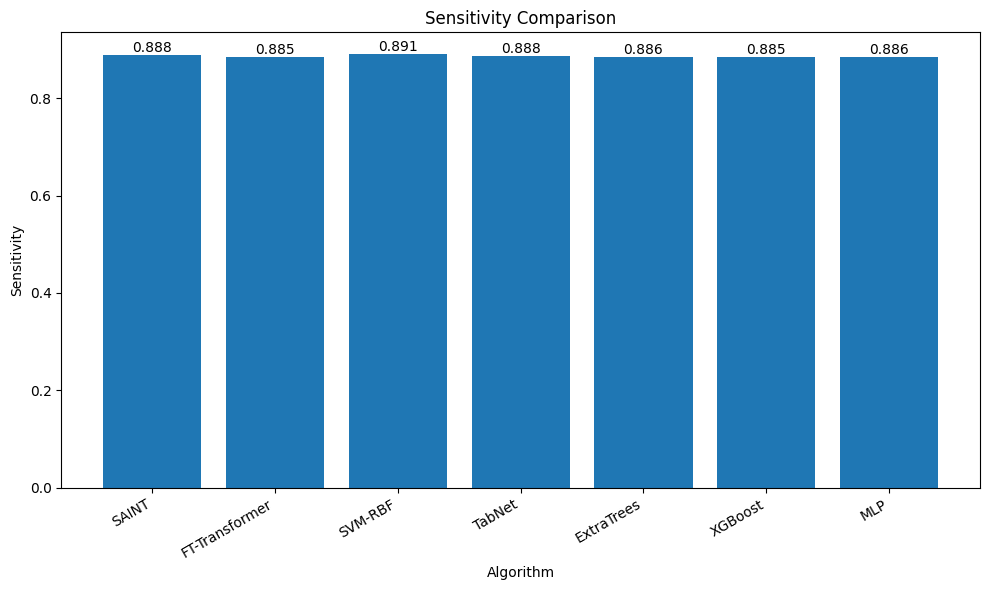

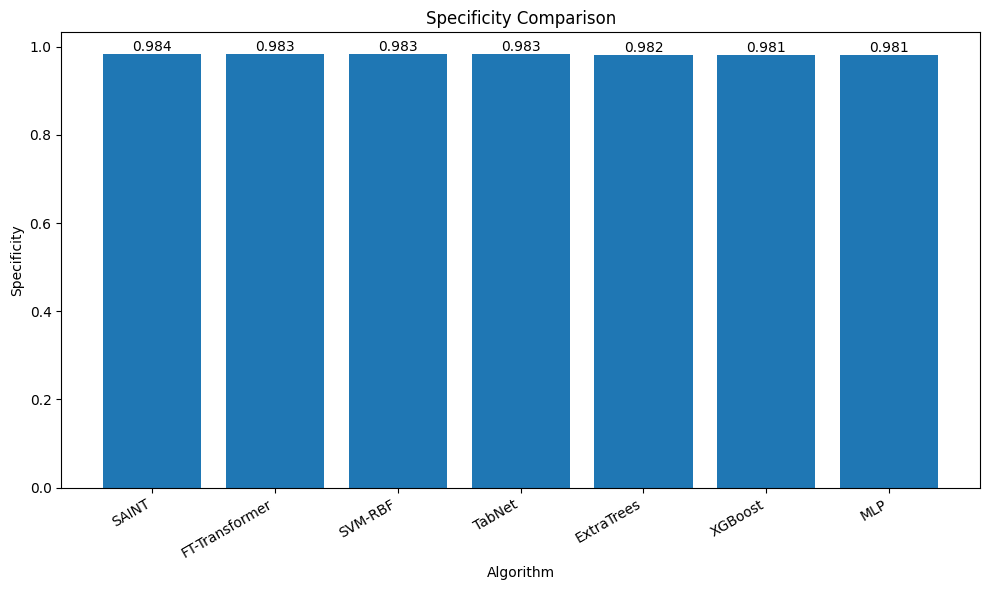

In [31]:

metrics_to_plot = [
    ("Accuracy", 24), ("Precision", 25), ("Recall", 26), ("F1-Score", 27),
    ("Balanced Accuracy", 28), ("MCC", 29), ("Sensitivity", 30), ("Specificity", 31)
]

for metric, number in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(results_df["Model"], results_df[metric])
    plt.ylabel(metric)
    plt.xlabel("Algorithm")
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=30, ha="right")
    for bar, value in zip(bars, results_df[metric]):
        plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(f"{FIG}/{number}_{metric.lower().replace(' ', '_')}_comparison.png", dpi=300)
    plt.show()




## 35. SENSITIVITY VS SPECIFICITY


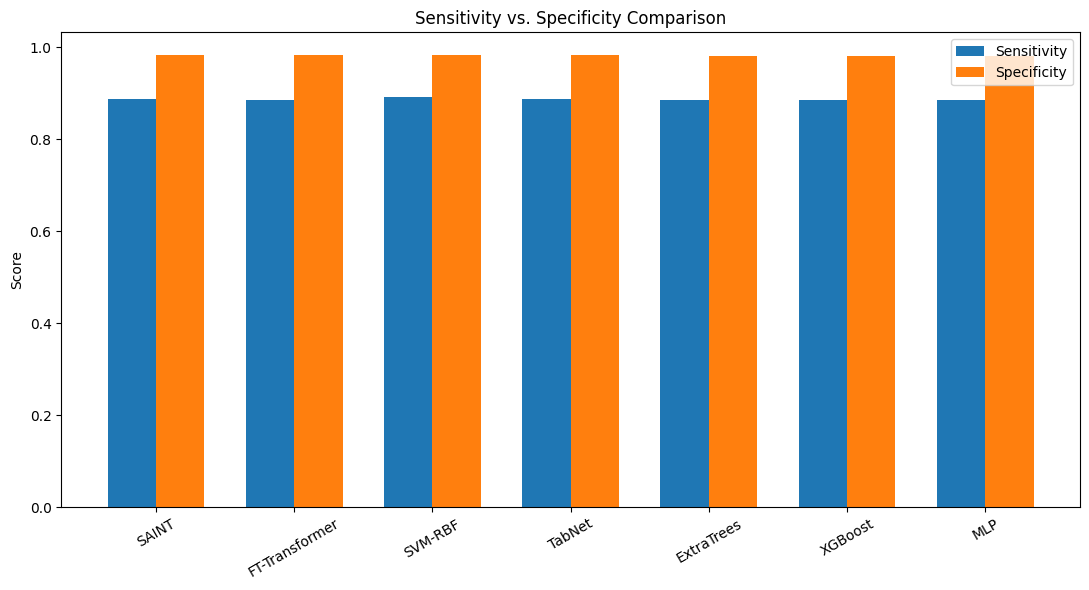

In [32]:

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, results_df["Sensitivity"], width, label="Sensitivity")
plt.bar(x + width/2, results_df["Specificity"], width, label="Specificity")
plt.xticks(x, results_df["Model"], rotation=30)
plt.ylabel("Score")
plt.title("Sensitivity vs. Specificity Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/32_sensitivity_vs_specificity.png", dpi=300)
plt.show()



## 36. CONFUSION MATRICES


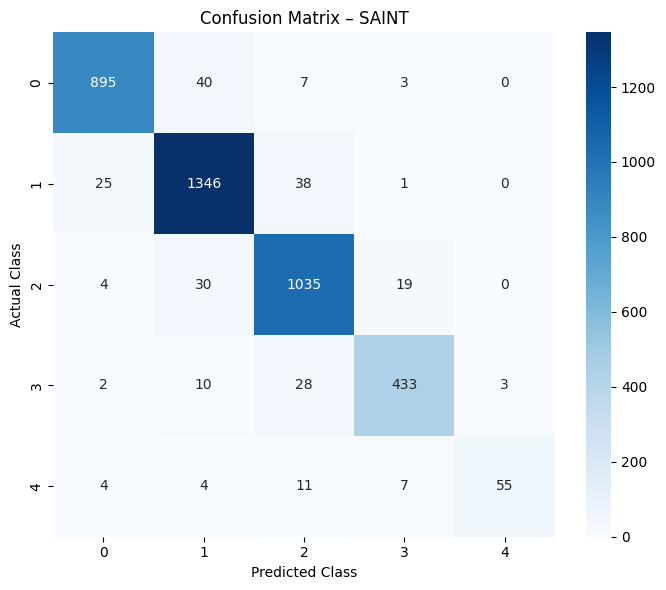

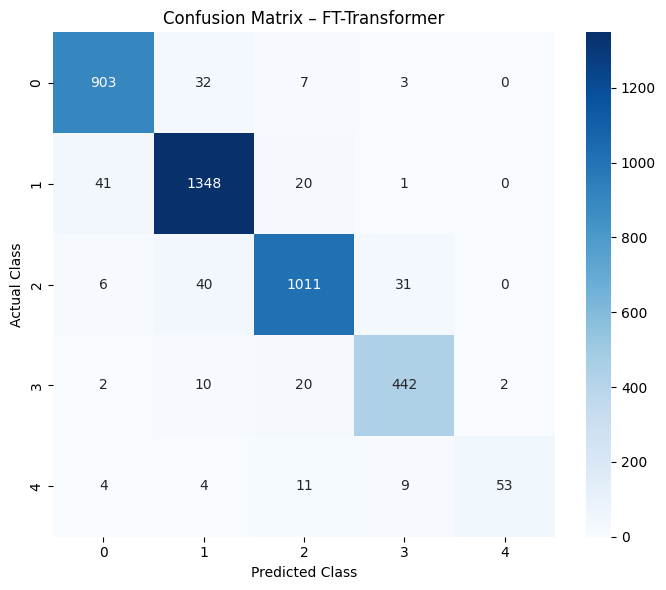

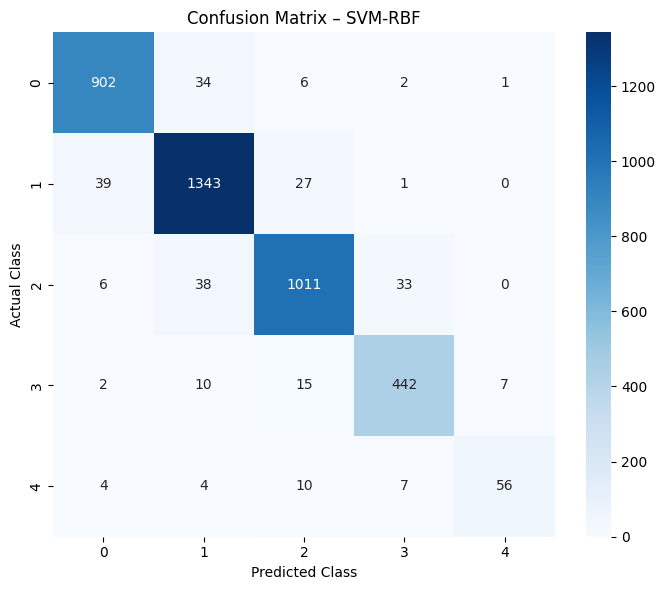

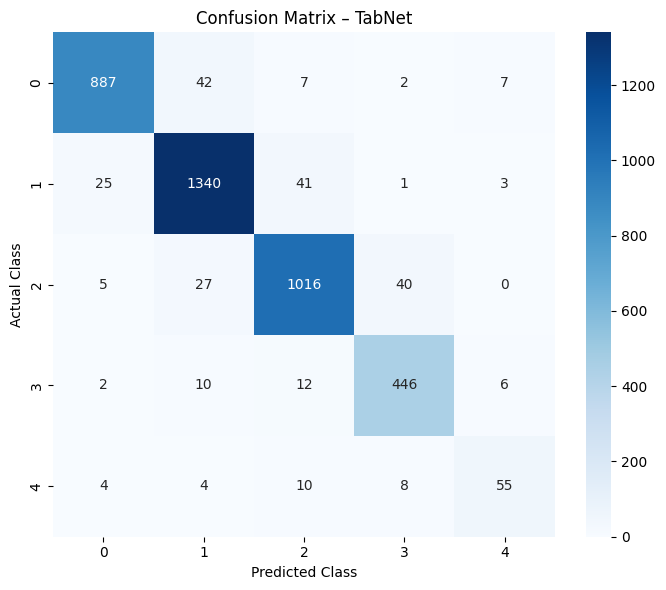

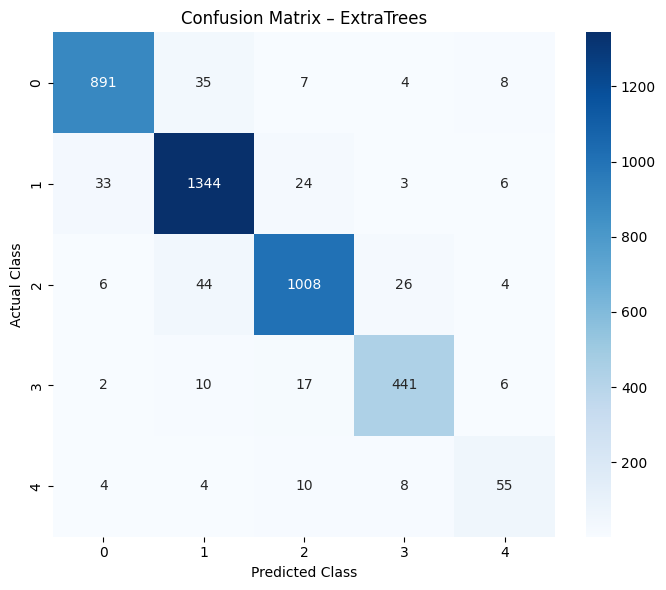

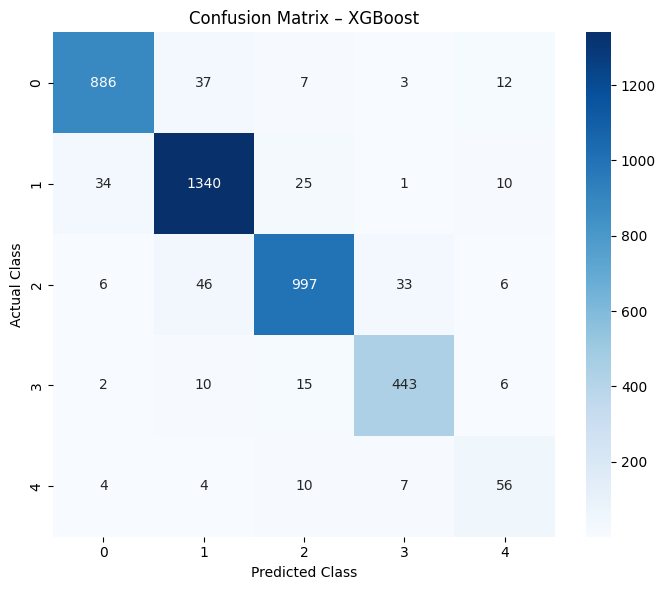

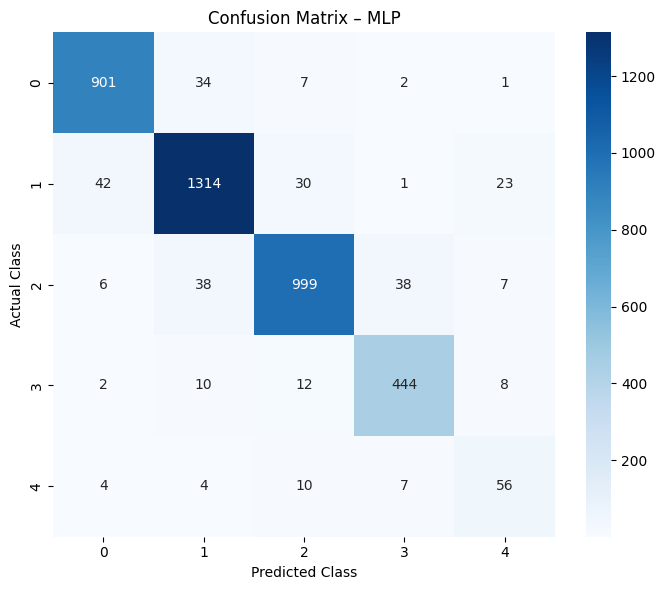

In [33]:

for name in results_df["Model"]:
    cm = confusion_matrix(y_test, predictions[name])
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"Confusion Matrix – {name}")
    plt.tight_layout()
    safe_name = name.replace("-", "_").replace(" ", "_")
    plt.savefig(f"{FIG}/33_confusion_matrix_{safe_name}.png", dpi=300)
    plt.show()




## 37. FINAL NORMALIZED CONFUSION MATRIX


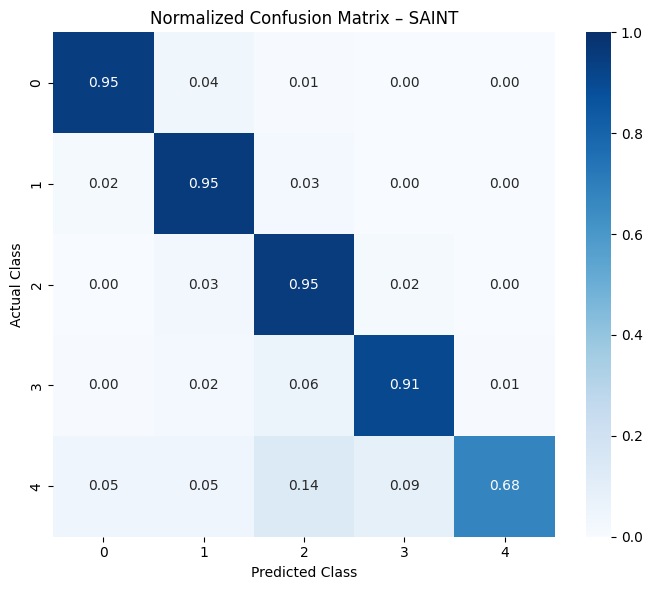

In [34]:

final_model_name = results_df.iloc[0]["Model"]

cm_norm = confusion_matrix(y_test, predictions[final_model_name], normalize="true")

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(f"Normalized Confusion Matrix – {final_model_name}")
plt.tight_layout()
plt.savefig(f"{FIG}/34_normalized_confusion_matrix_final.png", dpi=300)
plt.show()



## 38. MULTICLASS ROC


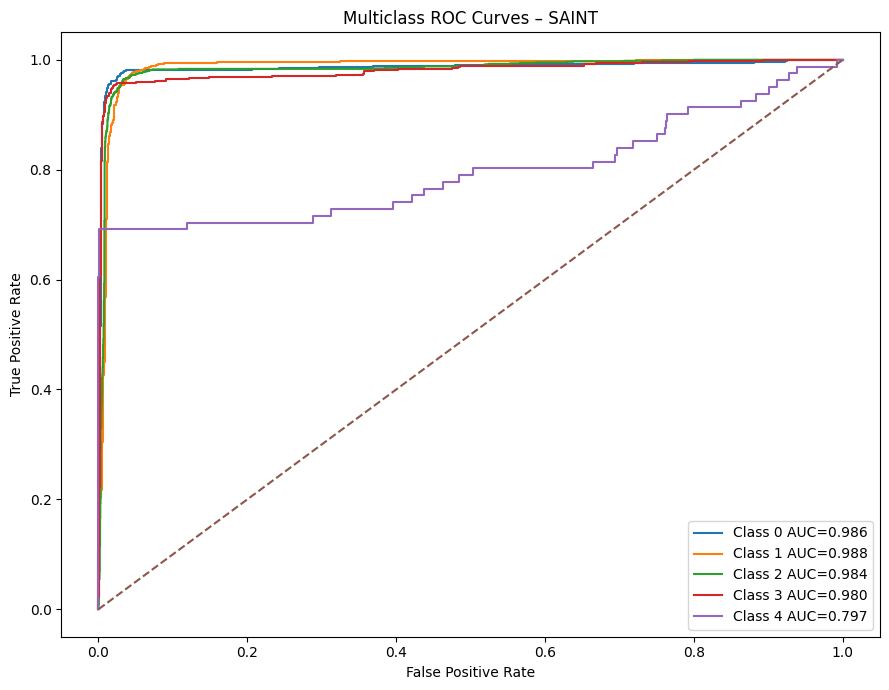

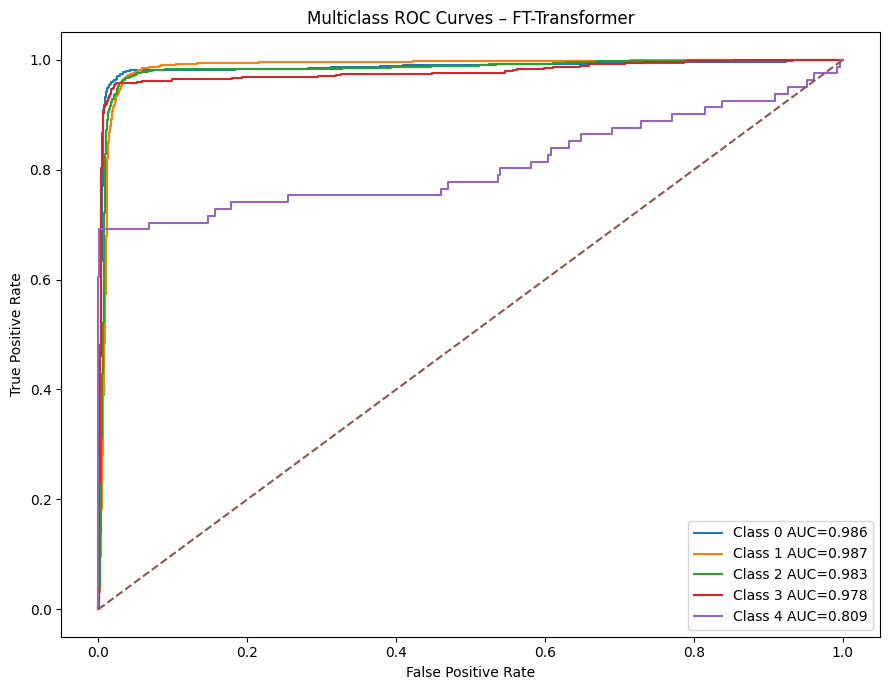

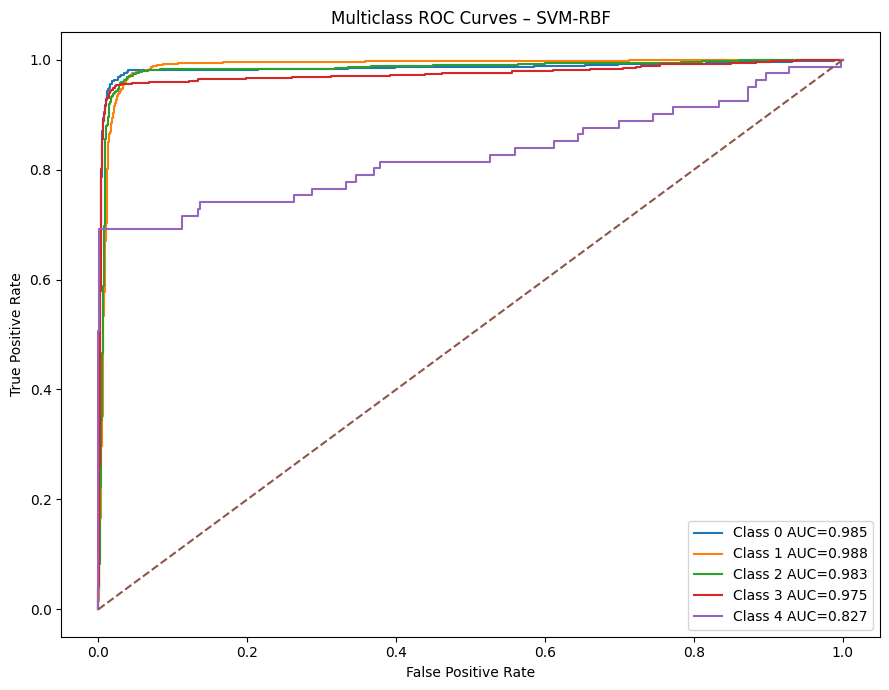

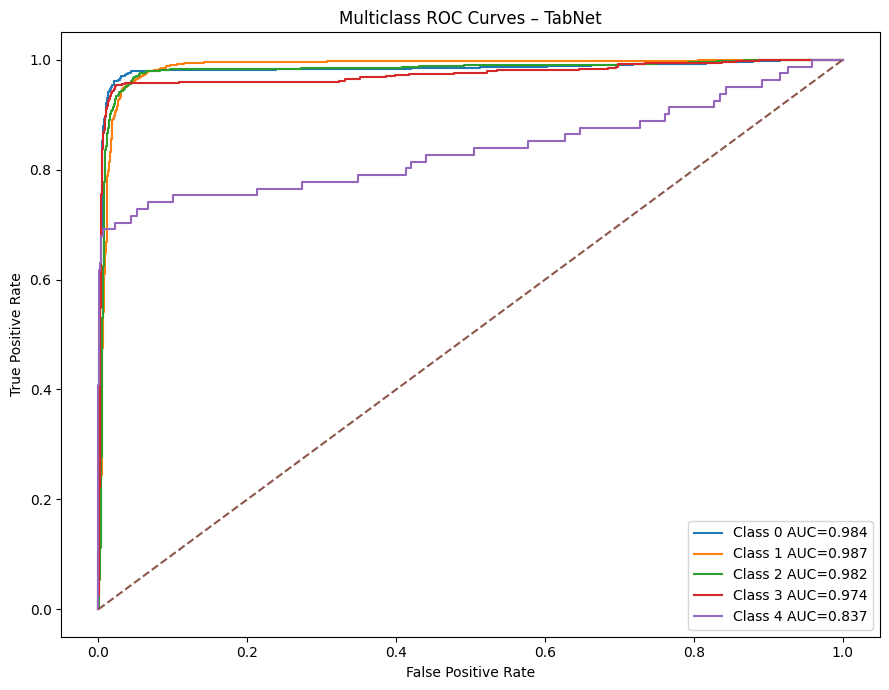

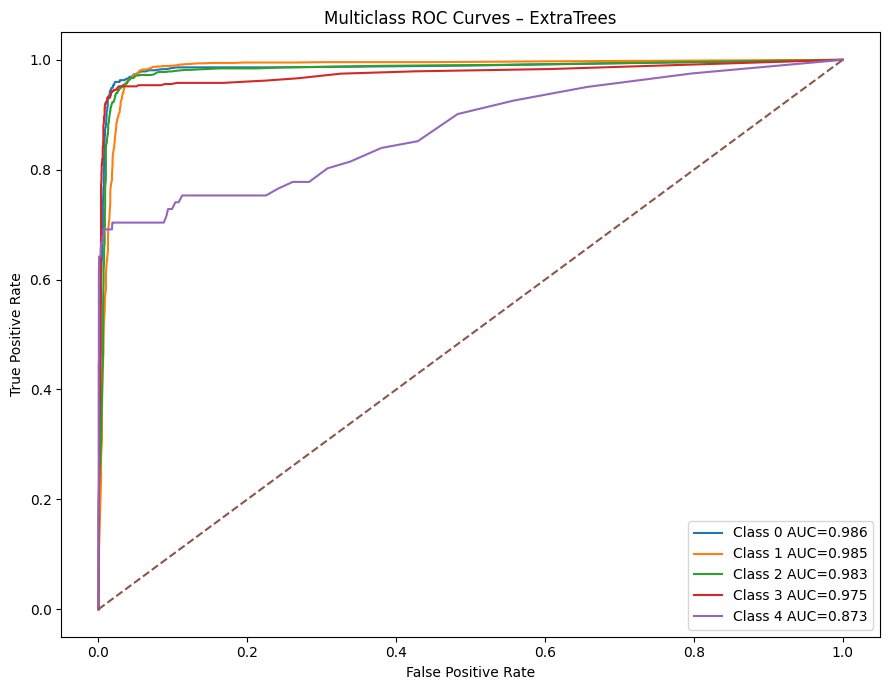

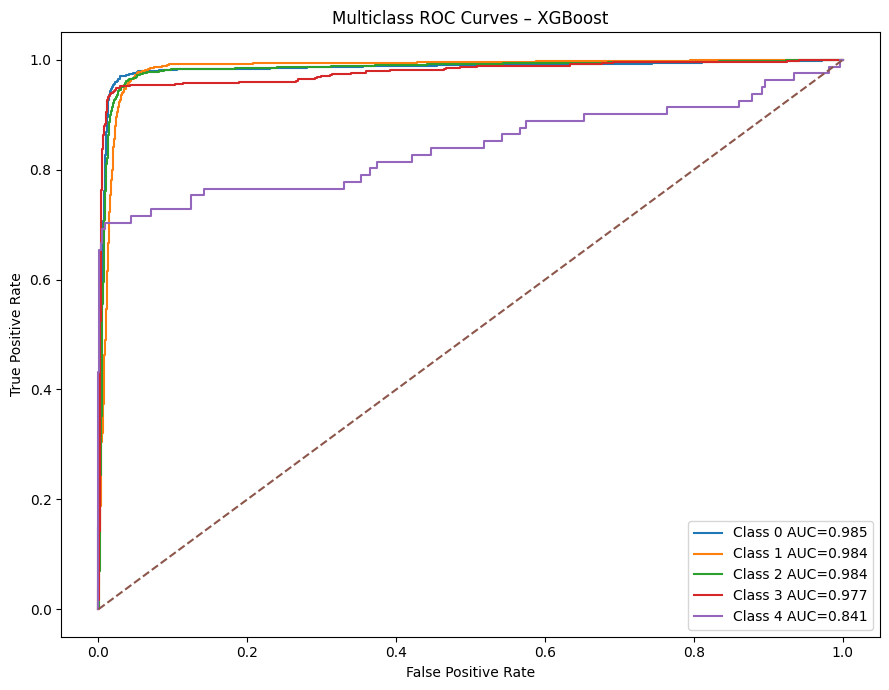

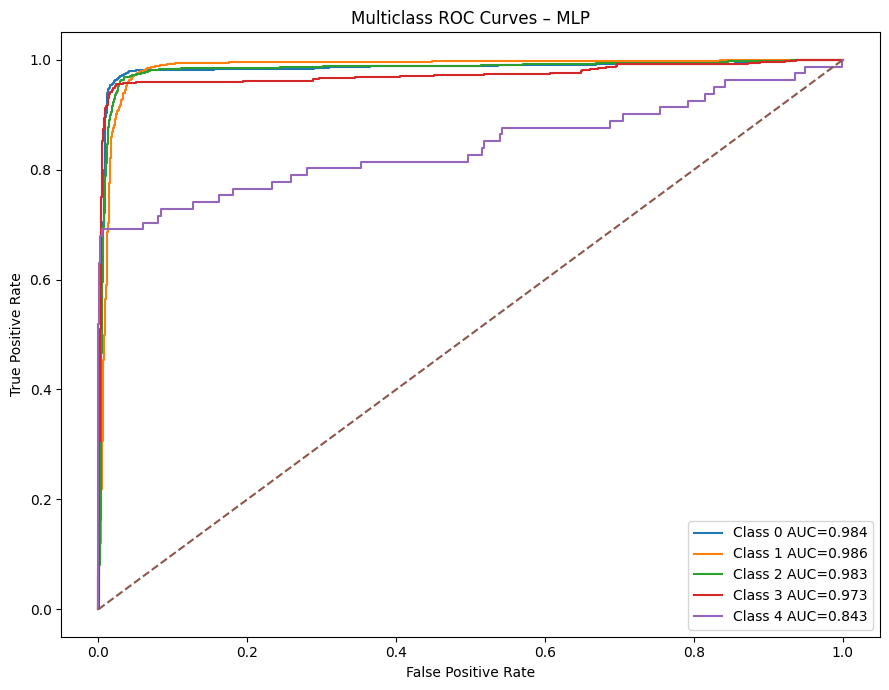

In [35]:

classes = np.sort(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

for name in results_df["Model"]:
    prob = probabilities[name]
    plt.figure(figsize=(9, 7))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {cls} AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multiclass ROC Curves – {name}")
    plt.legend()
    plt.tight_layout()
    safe_name = name.replace("-", "_").replace(" ", "_")
    plt.savefig(f"{FIG}/35_multiclass_roc_{safe_name}.png", dpi=300)
    plt.show()



## 39. PRECISION-RECALL CURVES


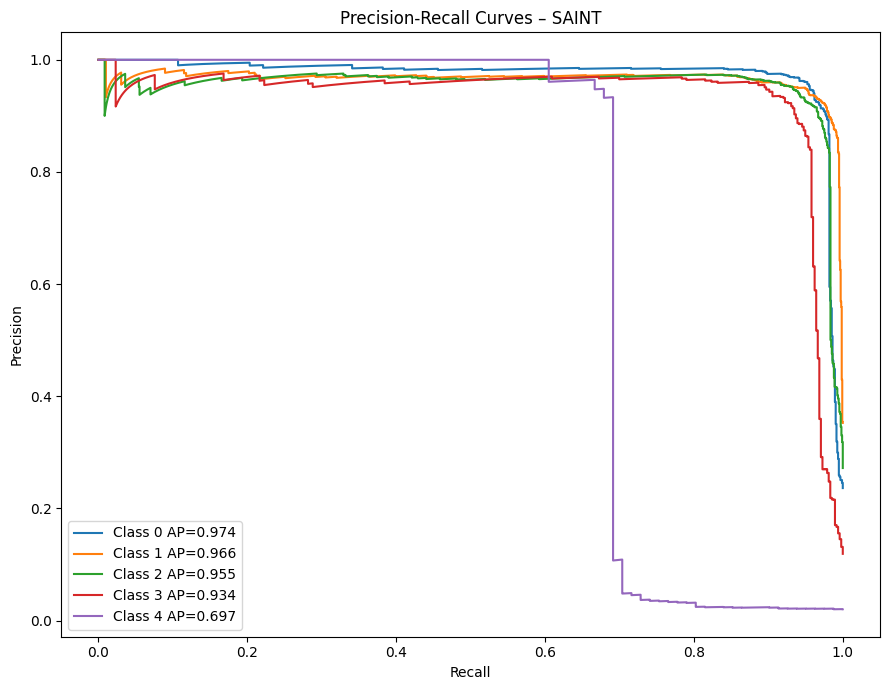

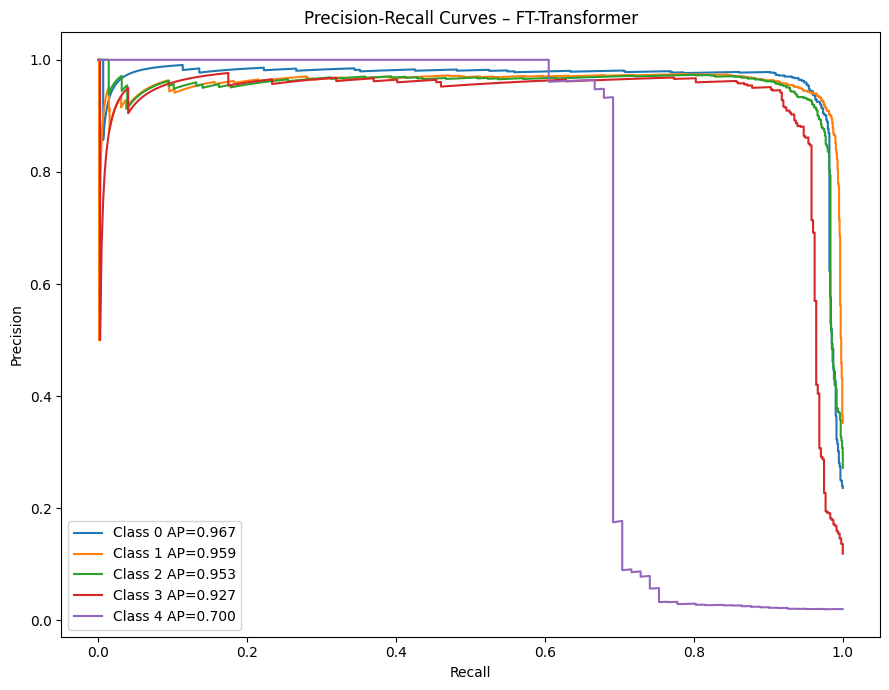

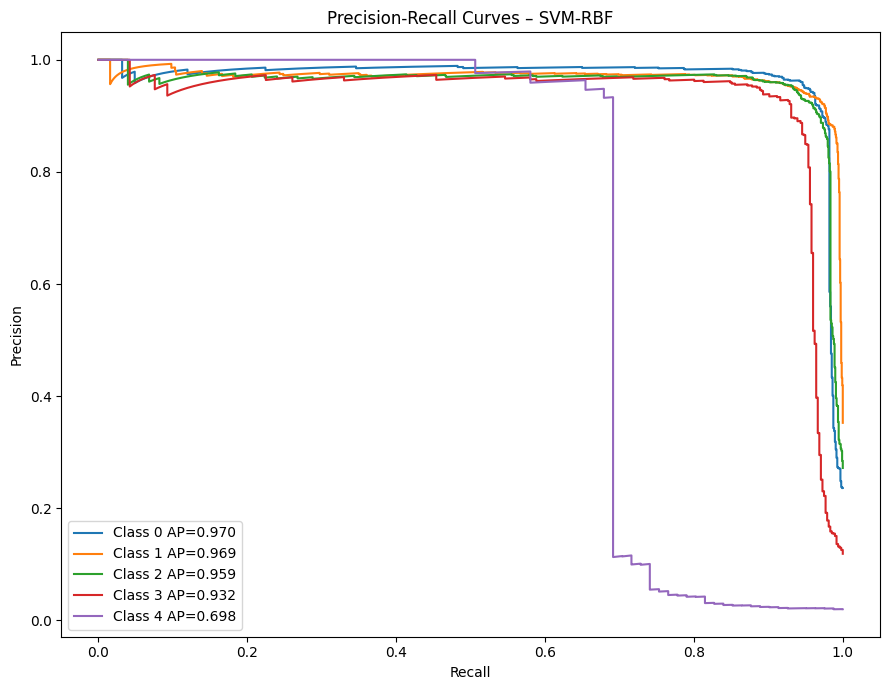

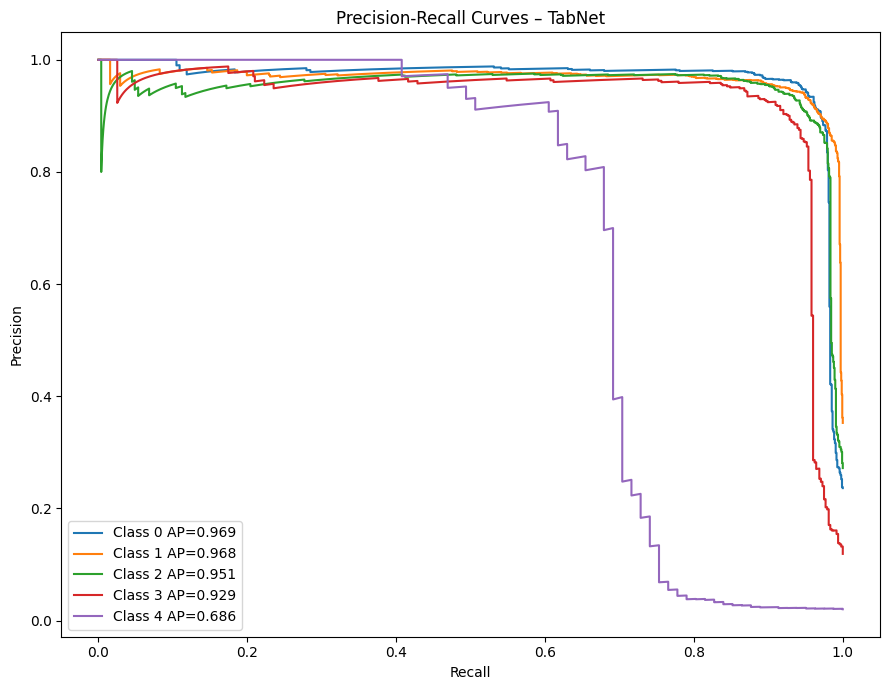

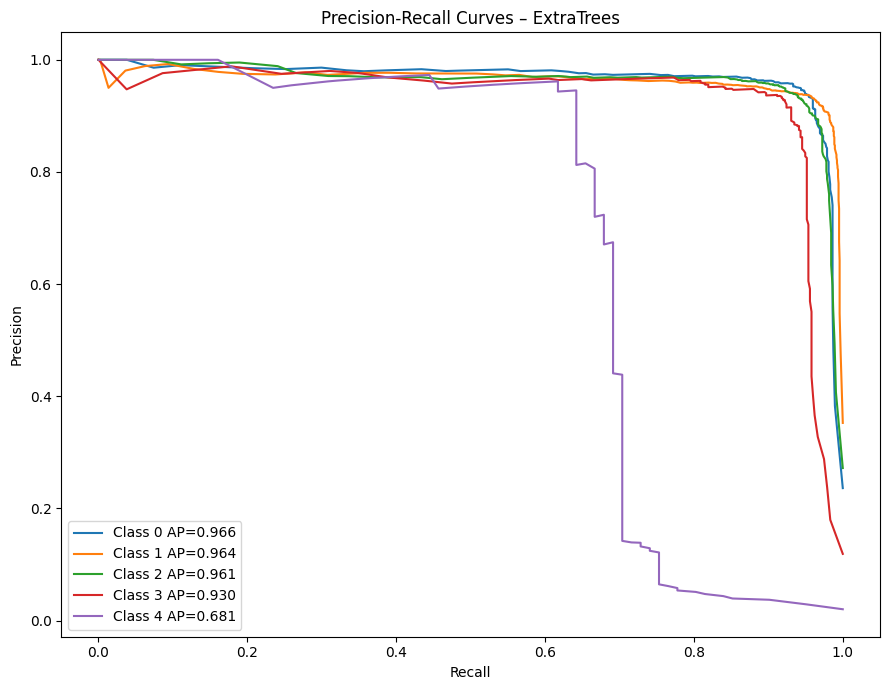

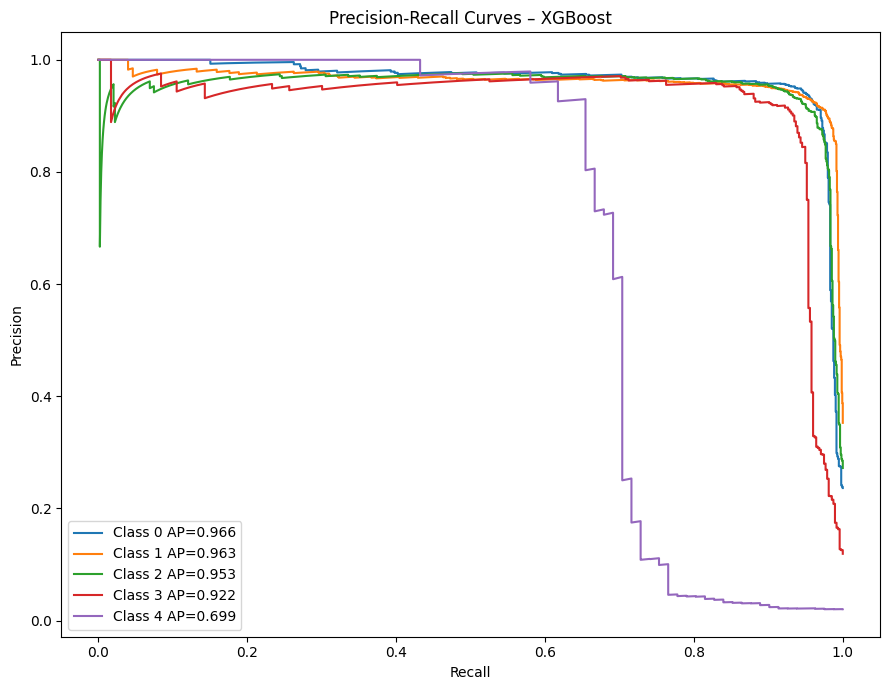

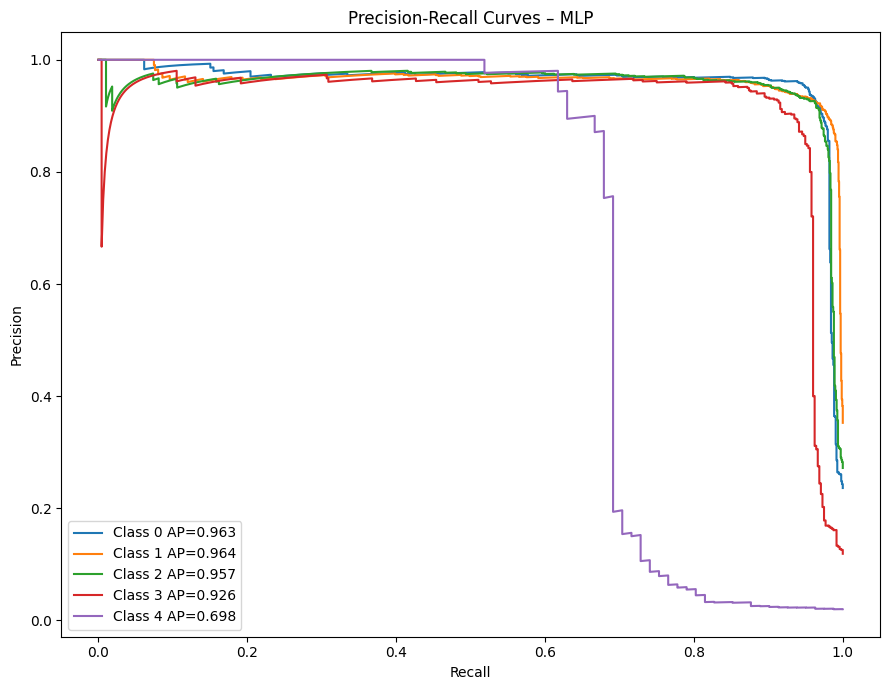

In [36]:

for name in results_df["Model"]:
    prob = probabilities[name]
    plt.figure(figsize=(9, 7))
    for i, cls in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], prob[:, i])
        ap = average_precision_score(y_test_bin[:, i], prob[:, i])
        plt.plot(recall, precision, label=f"Class {cls} AP={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curves – {name}")
    plt.legend()
    plt.tight_layout()
    safe_name = name.replace("-", "_").replace(" ", "_")
    plt.savefig(f"{FIG}/36_precision_recall_{safe_name}.png", dpi=300)
    plt.show()




## 40. MACRO ROC-AUC COMPARISON


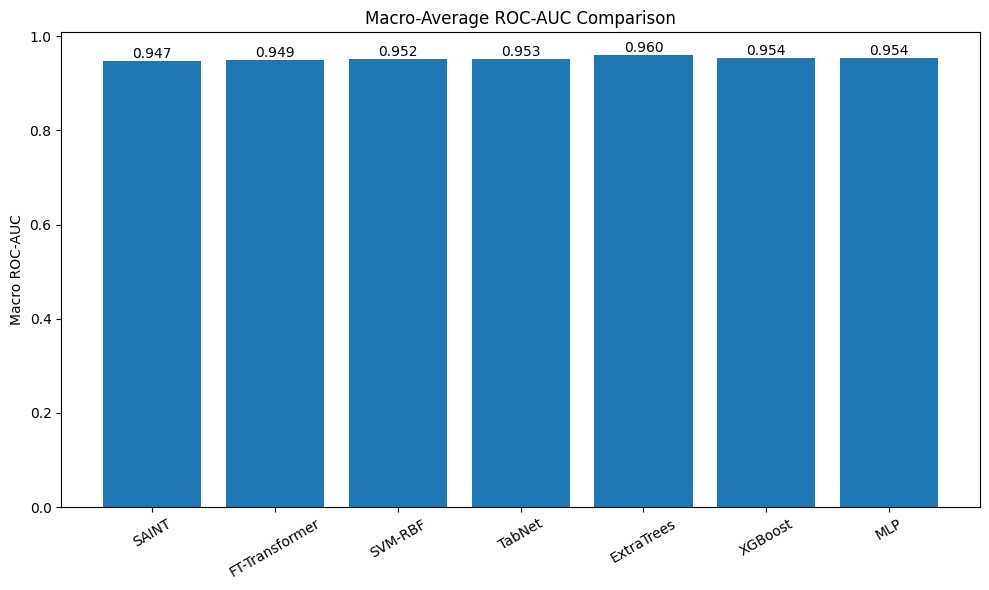

In [37]:

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.ylabel("Macro ROC-AUC")
plt.title("Macro-Average ROC-AUC Comparison")
plt.xticks(rotation=30)
for bar, value in zip(bars, results_df["ROC-AUC"]):
    plt.text(bar.get_x() + bar.get_width()/2, value, f"{value:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIG}/37_macro_roc_auc_comparison.png", dpi=300)
plt.show()



## 41. CLASS-WISE PERFORMANCE


,Model,Class,Precision,Recall,F1,Support
0,SAINT,0,0.962366,0.947090,0.954667,945.0
1,SAINT,1,0.941259,0.954610,0.947887,1410.0
2,SAINT,2,0.924933,0.951287,0.937925,1088.0
3,SAINT,3,0.935205,0.909664,0.922258,476.0
4,SAINT,4,0.948276,0.679012,0.791367,81.0
5,FT-Transformer,0,0.944561,0.955556,0.950026,945.0
6,FT-Transformer,1,0.940028,0.956028,0.947961,1410.0
7,FT-Transformer,2,0.945744,0.929228,0.937413,1088.0
8,FT-Transformer,3,0.909465,0.928571,0.918919,476.0
9,FT-Transformer,4,0.963636,0.654321,0.779412,81.0


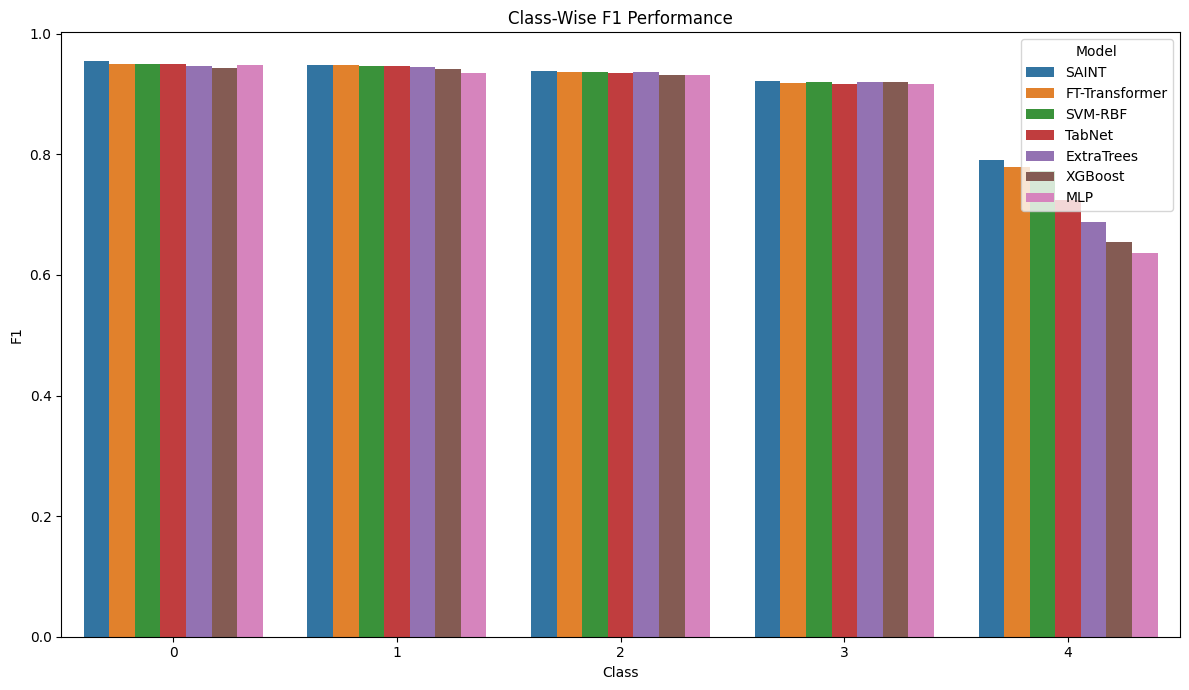

In [38]:

class_rows = []
for name in results_df["Model"]:
    report = classification_report(y_test, predictions[name], output_dict=True, zero_division=0)
    for cls in classes:
        class_rows.append({
            "Model": name, "Class": cls,
            "Precision": report[str(cls)]["precision"],
            "Recall": report[str(cls)]["recall"],
            "F1": report[str(cls)]["f1-score"],
            "Support": report[str(cls)]["support"]
        })

class_df = pd.DataFrame(class_rows)
class_df.to_csv(f"{TAB}/class_wise_performance.csv", index=False)
display(class_df)

plt.figure(figsize=(12, 7))
sns.barplot(data=class_df, x="Class", y="F1", hue="Model")
plt.title("Class-Wise F1 Performance")
plt.tight_layout()
plt.savefig(f"{FIG}/38_class_wise_performance.png", dpi=300)
plt.show()



## 42. BEFORE VS AFTER SMOTE


In [39]:

comparison_model = "XGBoost"
print("\nBefore vs After SMOTE:", comparison_model)

imbalanced_model = XGBClassifier(
    objective="multi:softprob", num_class=len(classes), eval_metric="mlogloss",
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1
)
imbalanced_model.fit(X_train_pca, y_train)

pred_before = imbalanced_model.predict(X_test_pca)
prob_before = imbalanced_model.predict_proba(X_test_pca)

before_metrics = calculate_metrics(y_test, pred_before, prob_before, "Before SMOTE")
after_metrics = calculate_metrics(y_test, predictions[comparison_model], probabilities[comparison_model], "After SMOTE")

smote_comparison = pd.DataFrame([before_metrics, after_metrics])
smote_comparison.to_csv(f"{TAB}/smote_before_after_metrics.csv", index=False)
display(smote_comparison)





Before vs After SMOTE: XGBoost


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,MCC,Sensitivity,Specificity,ROC-AUC
0,Before SMOTE,0.9385,0.937480,0.886755,0.908049,0.886755,0.915744,0.886755,0.982807,0.952594
1,After SMOTE,0.9305,0.872187,0.885262,0.878264,0.885262,0.905103,0.885262,0.981351,0.954134


## 43. MODEL PERFORMANCE BEFORE VS AFTER SMOTE


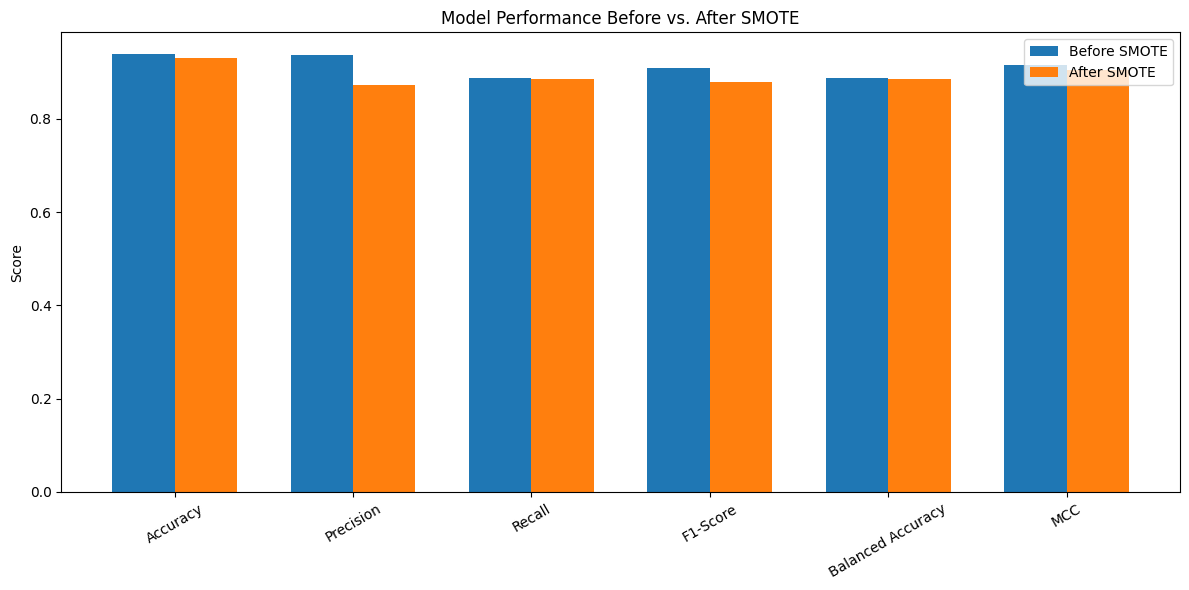

In [40]:

metrics_smote = ["Accuracy", "Precision", "Recall", "F1-Score", "Balanced Accuracy", "MCC"]
x = np.arange(len(metrics_smote))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, smote_comparison.iloc[0][metrics_smote], width, label="Before SMOTE")
plt.bar(x + width/2, smote_comparison.iloc[1][metrics_smote], width, label="After SMOTE")
plt.xticks(x, metrics_smote, rotation=30)
plt.ylabel("Score")
plt.title("Model Performance Before vs. After SMOTE")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/50_model_performance_before_after_smote.png", dpi=300)
plt.show()




## 44. SENSITIVITY / SPECIFICITY BEFORE VS AFTER


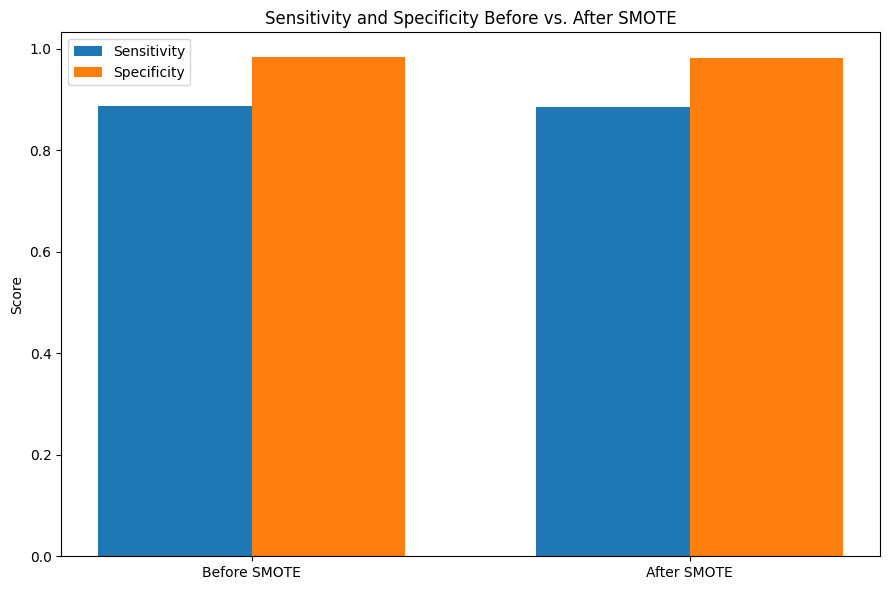

In [41]:

plt.figure(figsize=(9, 6))
x = np.arange(2)
plt.bar(x - width/2, smote_comparison["Sensitivity"], width, label="Sensitivity")
plt.bar(x + width/2, smote_comparison["Specificity"], width, label="Specificity")
plt.xticks(x, ["Before SMOTE", "After SMOTE"])
plt.ylabel("Score")
plt.title("Sensitivity and Specificity Before vs. After SMOTE")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/51_sensitivity_specificity_smote.png", dpi=300)
plt.show()



## 45. CONFUSION MATRIX BEFORE VS AFTER SMOTE


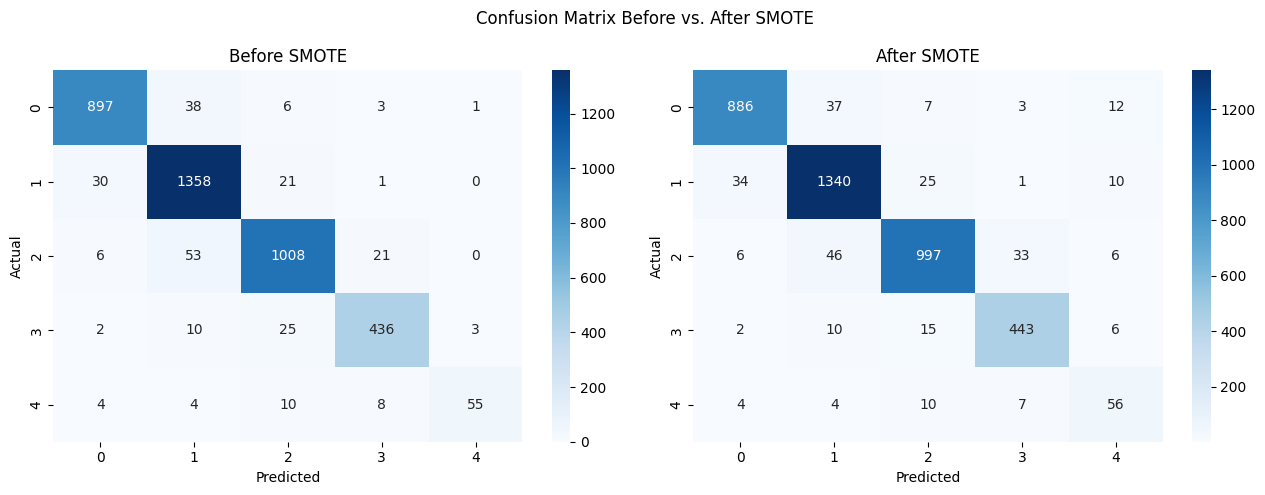

In [42]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_before = confusion_matrix(y_test, pred_before)
cm_after = confusion_matrix(y_test, predictions[comparison_model])

sns.heatmap(cm_before, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_after, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Before vs. After SMOTE")
plt.tight_layout()
plt.savefig(f"{FIG}/52_confusion_matrix_before_after_smote.png", dpi=300)
plt.show()



## 46. CROSS-VALIDATION SCORE DISTRIBUTION


In [43]:

cv_scores = {}

for name in ["XGBoost", "SVM-RBF", "MLP", "ExtraTrees"]:
    model = best_models[name]
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cv_fast.split(X_train_smote, y_train_smote)):
        model.fit(X_train_smote[train_idx], y_train_smote.iloc[train_idx])
        pred = model.predict(X_train_smote[val_idx])
        score = f1_score(y_train_smote.iloc[val_idx], pred, average="macro")
        fold_scores.append(score)

    cv_scores[name] = fold_scores

cv_df = pd.DataFrame(cv_scores)
cv_df.to_csv(f"{TAB}/cross_validation_scores.csv", index=False)
display(cv_df)




,XGBoost,SVM-RBF,MLP,ExtraTrees
0,0.927675,0.898966,0.897957,0.944754
1,0.925038,0.895638,0.891088,0.940729
2,0.920118,0.894240,0.894868,0.939993


## 47. CROSS-VALIDATION SCORE DISTRIBUTION FIGURE


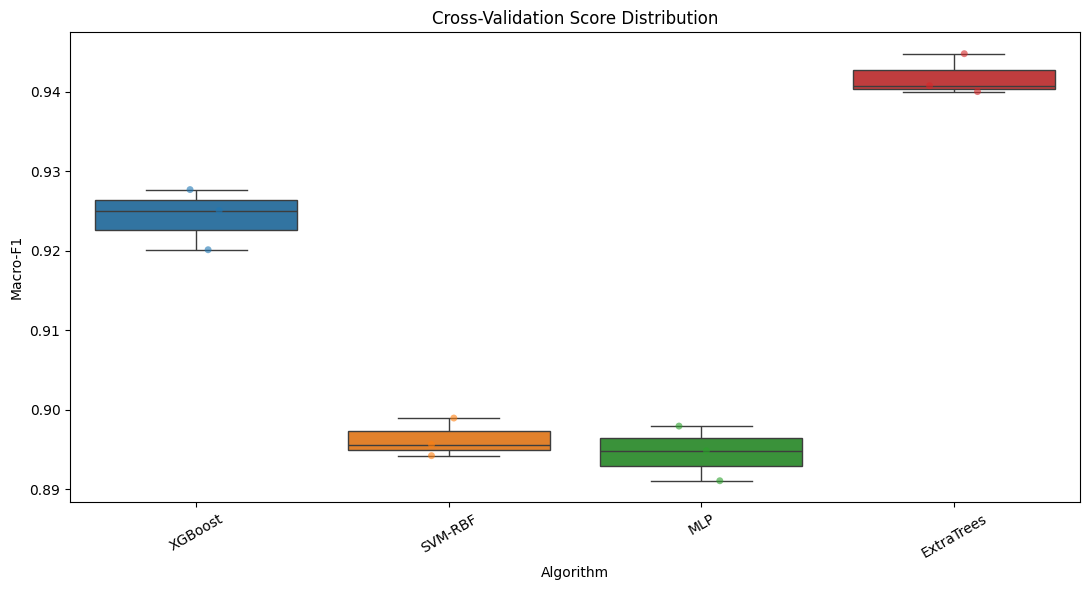

In [44]:

plt.figure(figsize=(11, 6))
sns.boxplot(data=cv_df)
sns.stripplot(data=cv_df, size=5, alpha=0.6)
plt.ylabel("Macro-F1")
plt.xlabel("Algorithm")
plt.title("Cross-Validation Score Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{FIG}/41_cross_validation_score_distribution.png", dpi=300)
plt.show()


## 48. STATISTICAL SIGNIFICANCE


In [45]:

reference_name = "XGBoost"
stat_rows = []

for name in cv_df.columns:
    if name == reference_name:
        continue
    try:
        statistic, p_value = wilcoxon(cv_df[reference_name], cv_df[name])
    except Exception:
        statistic, p_value = np.nan, np.nan

    stat_rows.append({
        "Reference_Model": reference_name,
        "Compared_Model": name,
        "Wilcoxon_Statistic": statistic,
        "p_value": p_value,
        "Significant_at_0.05": (p_value < 0.05 if not np.isnan(p_value) else False)
    })

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(f"{TAB}/statistical_significance_comparison.csv", index=False)
display(stat_df)



,Reference_Model,Compared_Model,Wilcoxon_Statistic,p_value,Significant_at_0.05
0,XGBoost,SVM-RBF,0.0,0.25,False
1,XGBoost,MLP,0.0,0.25,False
2,XGBoost,ExtraTrees,0.0,0.25,False


## 49. FEATURE IMPORTANCE


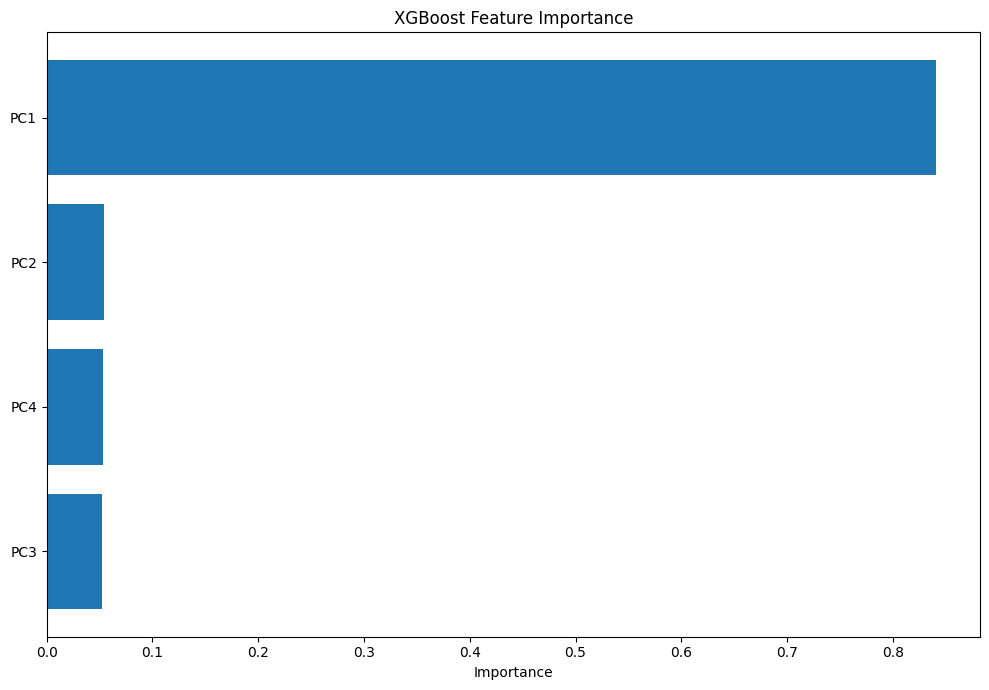

In [46]:

if "XGBoost" in best_models:
    xgb_model = best_models["XGBoost"]
    importance = xgb_model.feature_importances_

    importance_df = pd.DataFrame({
        "PCA_Component": [f"PC{i+1}" for i in range(len(importance))],
        "Importance": importance
    }).sort_values("Importance", ascending=False)

    importance_df.to_csv(f"{TAB}/xgboost_feature_importance.csv", index=False)

    plt.figure(figsize=(10, 7))
    top_imp = importance_df.head(15).sort_values("Importance")
    plt.barh(top_imp["PCA_Component"], top_imp["Importance"])
    plt.xlabel("Importance")
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig(f"{FIG}/42_feature_importance.png", dpi=300)
    plt.show()




## 50. SHAP


SHAP skipped: index 4 is out of bounds for axis 1 with size 4


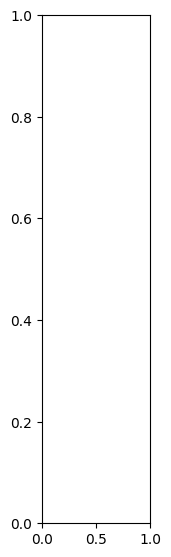

In [47]:

try:
    sample_size = min(1000, len(X_test_pca))
    X_shap = X_test_pca[:sample_size]

    explainer = shap.TreeExplainer(best_models["XGBoost"])
    shap_values = explainer.shap_values(X_shap)

    shap.summary_plot(shap_values, X_shap, show=False)
    plt.title("SHAP Summary Plot – XGBoost")
    plt.tight_layout()
    plt.savefig(f"{FIG}/43_shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("SHAP skipped:", e)




## 51. CALIBRATION CURVE


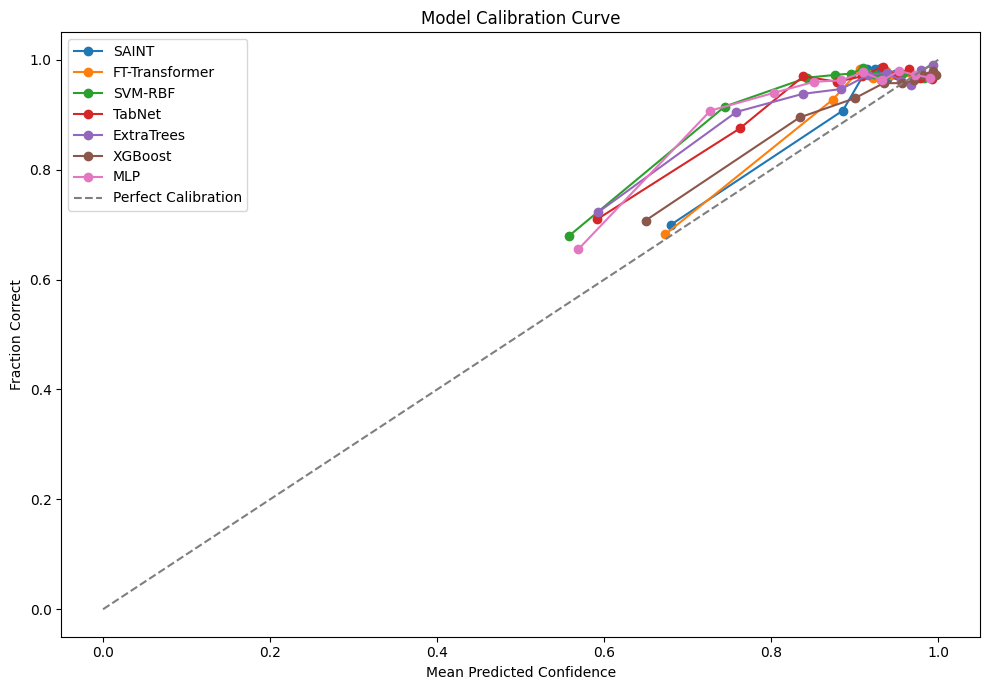

In [48]:

plt.figure(figsize=(10, 7))

for name in results_df["Model"].tolist():
    prob = probabilities[name]
    confidence = np.max(prob, axis=1)
    correct = (predictions[name] == np.asarray(y_test)).astype(int)

    fraction_pos, mean_pred = calibration_curve(correct, confidence, n_bins=10, strategy="quantile")
    plt.plot(mean_pred, fraction_pos, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Confidence")
plt.ylabel("Fraction Correct")
plt.title("Model Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/45_model_calibration_curve.png", dpi=300)
plt.show()



## 52. PREDICTION ERROR ANALYSIS


,Model,Total_Test_Samples,Correct,Incorrect,Error_Rate
0,SAINT,4000,3764,236,0.05900
1,FT-Transformer,4000,3757,243,0.06075
2,SVM-RBF,4000,3754,246,0.06150
3,TabNet,4000,3744,256,0.06400
4,ExtraTrees,4000,3739,261,0.06525
5,XGBoost,4000,3722,278,0.06950
6,MLP,4000,3714,286,0.07150


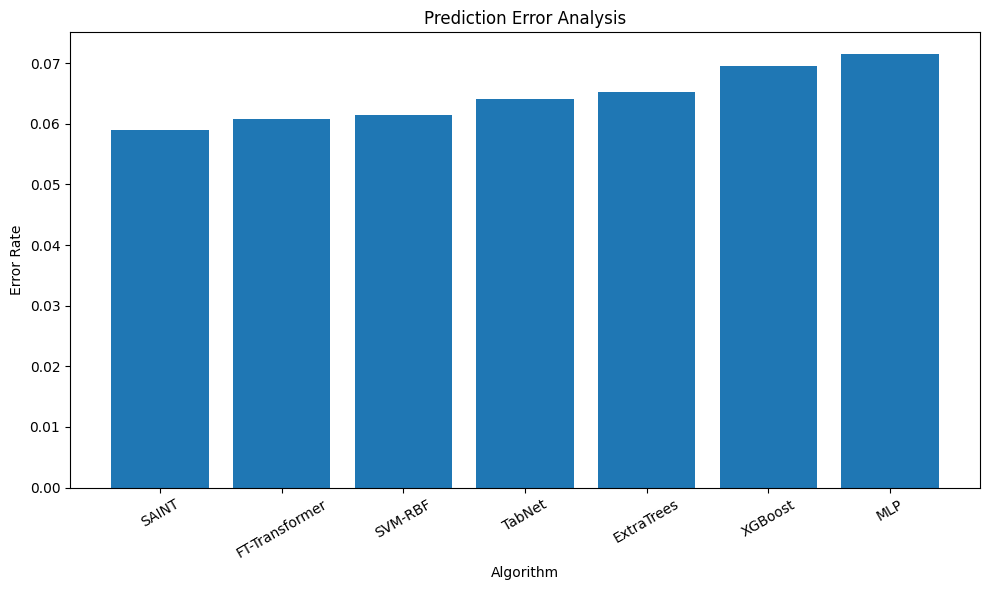

In [49]:

error_rows = []

for name in results_df["Model"].tolist():
    errors = predictions[name] != np.asarray(y_test)
    error_rows.append({
        "Model": name,
        "Total_Test_Samples": len(y_test),
        "Correct": np.sum(~errors),
        "Incorrect": np.sum(errors),
        "Error_Rate": np.mean(errors)
    })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(f"{TAB}/prediction_error_analysis.csv", index=False)
display(error_df)

plt.figure(figsize=(10, 6))
plt.bar(error_df["Model"], error_df["Error_Rate"])
plt.ylabel("Error Rate")
plt.xlabel("Algorithm")
plt.title("Prediction Error Analysis")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f"{FIG}/46_prediction_error_analysis.png", dpi=300)
plt.show()



## 53. ROBUSTNESS ANALYSIS


,Noise_Level,Model,Accuracy,Macro_F1,Balanced_Accuracy
0,0.00,XGBoost,0.93175,0.882668,0.885583
1,0.00,SVM-RBF,0.93525,0.900523,0.888645
2,0.00,MLP,0.92850,0.865422,0.883790
3,0.00,ExtraTrees,0.93100,0.885390,0.886131
4,0.00,TabNet,0.93600,0.894158,0.887758
5,0.00,FT-Transformer,0.93925,0.906746,0.884741
6,0.00,SAINT,0.94100,0.910821,0.888333
7,0.01,XGBoost,0.92975,0.878356,0.884350
8,0.01,SVM-RBF,0.93525,0.900523,0.888645
9,0.01,MLP,0.92925,0.867006,0.884021


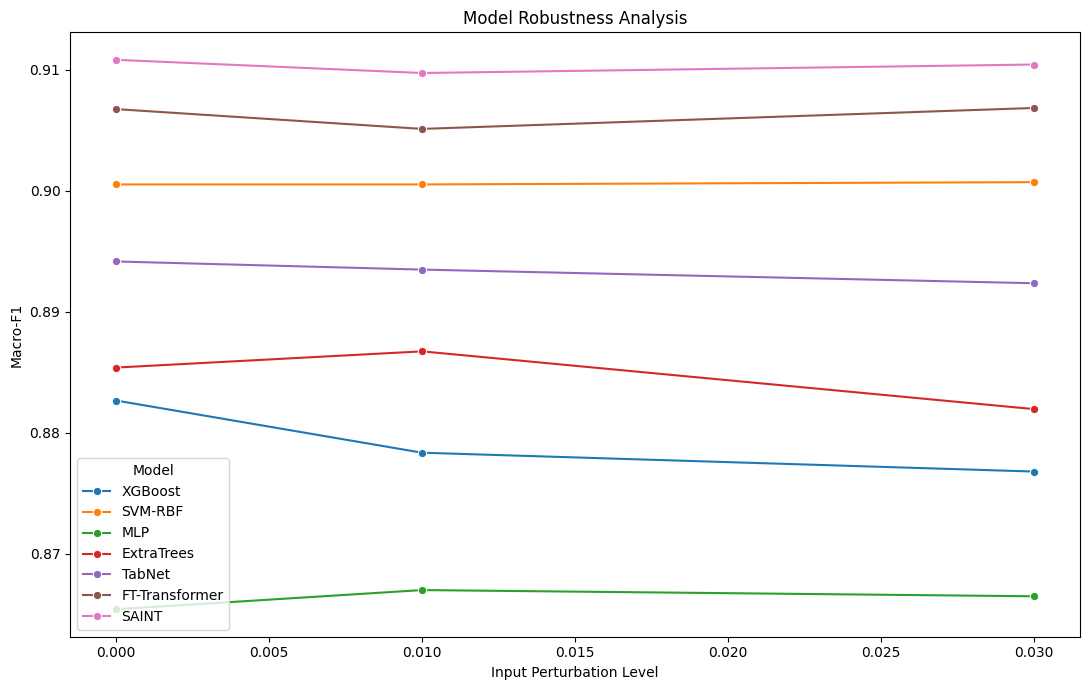

In [50]:

robustness_rows = []
noise_levels = [0.00, 0.01, 0.03]
rng = np.random.default_rng(RANDOM_STATE)

for noise in noise_levels:
    X_robust = X_test_pca + rng.normal(0, noise, X_test_pca.shape)

    for name, model in best_models.items():
        pred, prob = get_predictions(model, name, X_robust)
        robustness_rows.append({
            "Noise_Level": noise,
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Macro_F1": f1_score(y_test, pred, average="macro"),
            "Balanced_Accuracy": balanced_accuracy_score(y_test, pred)
        })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.to_csv(f"{TAB}/model_robustness_analysis.csv", index=False)
display(robustness_df)

plt.figure(figsize=(11, 7))
sns.lineplot(data=robustness_df, x="Noise_Level", y="Macro_F1", hue="Model", marker="o")
plt.title("Model Robustness Analysis")
plt.xlabel("Input Perturbation Level")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.savefig(f"{FIG}/47_model_robustness_analysis.png", dpi=300)
plt.show()



## 54. FINAL MODEL SUMMARY


In [51]:

final_summary = results_df.copy()
final_summary.insert(0, "Rank_by_Macro_F1", np.arange(1, len(final_summary) + 1))
final_summary.to_csv(f"{TAB}/48_final_model_performance_summary.csv", index=False)

print("\n" + "=" * 80)
print("FINAL MODEL")
print("=" * 80)
print("Model:", final_model_name)

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "Balanced Accuracy",
               "MCC", "Sensitivity", "Specificity", "ROC-AUC"]:
    print(f"{metric}: {final_summary.iloc[0][metric]:.4f}")




FINAL MODEL
Model: SAINT
Accuracy: 0.9410
Precision: 0.9424
Recall: 0.8883
F1-Score: 0.9108
Balanced Accuracy: 0.8883
MCC: 0.9192
Sensitivity: 0.8883
Specificity: 0.9836
ROC-AUC: 0.9470


## 55. SAVE MODELS


In [52]:

for name, model in best_models.items():
    safe_name = name.replace("-", "_").replace(" ", "_")
    try:
        if name in ["FT-Transformer", "SAINT"]:
            torch.save(model.state_dict(), f"{MOD}/{safe_name}.pth")
        elif name == "TabNet":
            model.save_model(f"{MOD}/{safe_name}")
        else:
            joblib.dump(model, f"{MOD}/{safe_name}.joblib")
    except Exception as e:
        print(f"Could not save {name}: {e}")




Successfully saved model at /content/flood_results/models/TabNet.zip


## 56. SAVE PREPROCESSING OBJECTS


In [53]:

joblib.dump(preprocessor, f"{MOD}/preprocessor.joblib")
joblib.dump(selector, f"{MOD}/feature_selector.joblib")
joblib.dump(pca, f"{MOD}/pca.joblib")



['/content/flood_results/models/pca.joblib']

## 57. COMPLETE EXCEL RESULTS


In [54]:

excel_path = f"{TAB}/complete_flood_ml_results_fast.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="Final_Metrics", index=False)
    tuning_df.to_excel(writer, sheet_name="Tuning", index=False)
    class_df.to_excel(writer, sheet_name="Classwise", index=False)
    dist_df.to_excel(writer, sheet_name="SMOTE_Distribution")
    cv_df.to_excel(writer, sheet_name="CV_Scores", index=False)
    stat_df.to_excel(writer, sheet_name="Statistics", index=False)
    smote_comparison.to_excel(writer, sheet_name="SMOTE_Comparison", index=False)
    error_df.to_excel(writer, sheet_name="Errors", index=False)
    robustness_df.to_excel(writer, sheet_name="Robustness", index=False)

print("\n" + "=" * 80)
print("FAST COMPLETE PIPELINE FINISHED")
print("=" * 80)
print("\nResults:", "/content/flood_results/")
print("\nFinal Model:", final_model_name)
print("\nFigures:", FIG)
print("\nTables:", TAB)
print("\nModels:", MOD)



FAST COMPLETE PIPELINE FINISHED

Results: /content/flood_results/

Final Model: SAINT

Figures: /content/flood_results/figures

Tables: /content/flood_results/tables

Models: /content/flood_results/models


In [55]:
# ================================================================
# EXTENDED SAINT MODEL ANALYSIS — APPEND TO END OF EXISTING PIPELINE
# ================================================================


import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

REQUIRED = [
    "best_models", "SAINT", "train_torch_model", "get_predictions",
    "calculate_metrics", "X_train_smote", "y_train_smote", "X_test_pca",
    "y_test", "X_train_pca", "y_train", "classes", "results_df",
    "predictions", "probabilities", "class_df", "TAB", "FIG", "MOD",
    "RANDOM_STATE", "device"
]
missing = [v for v in REQUIRED if v not in globals()]
if missing:
    raise RuntimeError(f"Run the main pipeline first. Missing: {missing}")

SAINT_NAME = "SAINT"
saint_model = best_models[SAINT_NAME]



## 58. 10-FOLD CROSS-VALIDATION STABILITY (ALL MODELS, INCLUDING SAINT)


10-FOLD CROSS-VALIDATION (ALL MODELS)

--- Fold 1/10 ---
XGBoost: Macro-F1 = 0.9324
SVM-RBF: Macro-F1 = 0.8964
MLP: Macro-F1 = 0.8985
ExtraTrees: Macro-F1 = 0.9494
TabNet: Macro-F1 = 0.9036
FT-Transformer: Macro-F1 = 0.8955
SAINT: Macro-F1 = 0.8940

--- Fold 2/10 ---
XGBoost: Macro-F1 = 0.9287
SVM-RBF: Macro-F1 = 0.9052
MLP: Macro-F1 = 0.9078
ExtraTrees: Macro-F1 = 0.9484
TabNet: Macro-F1 = 0.9057
FT-Transformer: Macro-F1 = 0.9017
SAINT: Macro-F1 = 0.8893

--- Fold 3/10 ---
XGBoost: Macro-F1 = 0.9297
SVM-RBF: Macro-F1 = 0.9024
MLP: Macro-F1 = 0.9026
ExtraTrees: Macro-F1 = 0.9496
TabNet: Macro-F1 = 0.9044
FT-Transformer: Macro-F1 = 0.9027
SAINT: Macro-F1 = 0.8988

--- Fold 4/10 ---
XGBoost: Macro-F1 = 0.9165
SVM-RBF: Macro-F1 = 0.8906
MLP: Macro-F1 = 0.8884
ExtraTrees: Macro-F1 = 0.9385
TabNet: Macro-F1 = 0.8767
FT-Transformer: Macro-F1 = 0.8879
SAINT: Macro-F1 = 0.8920

--- Fold 5/10 ---
XGBoost: Macro-F1 = 0.9354
SVM-RBF: Macro-F1 = 0.9017
MLP: Macro-F1 = 0.9035
ExtraTrees: Macro-F1 =

,mean,std,min,max
XGBoost,0.927402,0.005347,0.916538,0.935404
SVM-RBF,0.897020,0.004854,0.890632,0.905162
MLP,0.897628,0.006271,0.888361,0.907758
ExtraTrees,0.947584,0.003755,0.938500,0.952261
TabNet,0.896035,0.009069,0.876714,0.905703
FT-Transformer,0.896020,0.004458,0.887865,0.902748
SAINT,0.893968,0.003309,0.889295,0.898845


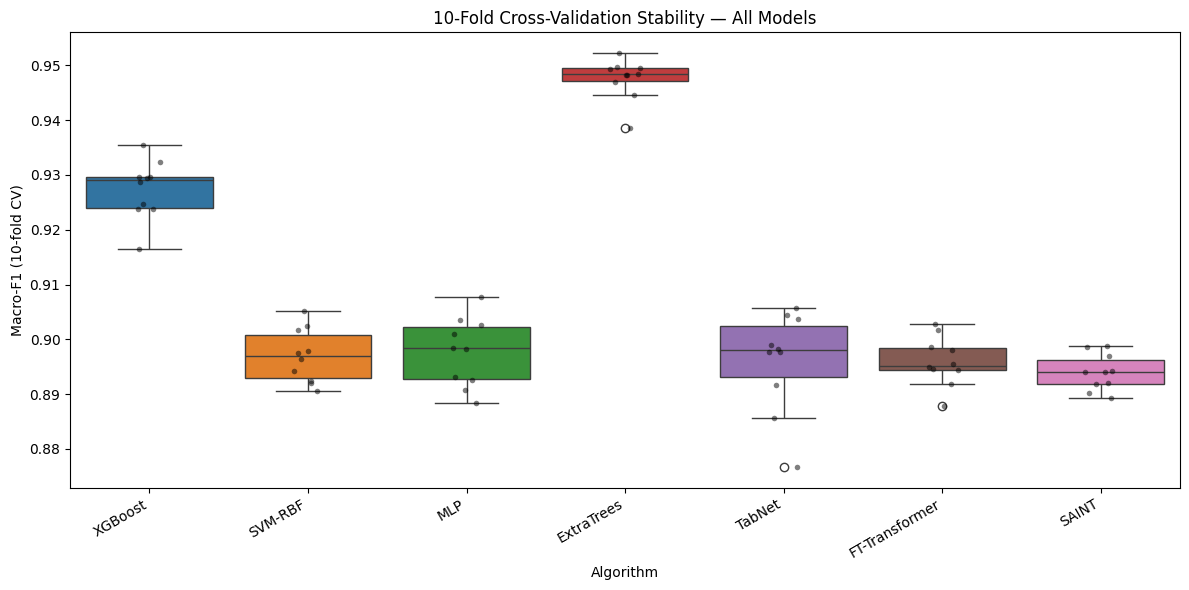

In [56]:

print("=" * 70)
print("10-FOLD CROSS-VALIDATION (ALL MODELS)")
print("=" * 70)

cv_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv10_scores = {name: [] for name in best_models.keys()}

X_smote_arr = np.asarray(X_train_smote)
y_smote_arr = np.asarray(y_train_smote)

for fold, (tr_idx, val_idx) in enumerate(cv_10.split(X_smote_arr, y_smote_arr)):
    Xtr, Xval = X_smote_arr[tr_idx], X_smote_arr[val_idx]
    ytr, yval = y_smote_arr[tr_idx], y_smote_arr[val_idx]
    print(f"\n--- Fold {fold + 1}/10 ---")

    for name, model in best_models.items():
        if name == "TabNet":
            m = TabNetClassifier(
                n_d=16, n_a=16, n_steps=4, gamma=1.3, lambda_sparse=1e-4,
                optimizer_fn=torch.optim.Adam, optimizer_params={"lr": 0.01},
                mask_type="entmax", seed=RANDOM_STATE, verbose=0
            )
            m.fit(Xtr.astype(np.float32), ytr, max_epochs=40, patience=8,
                  batch_size=1024, virtual_batch_size=128)
            pred = np.argmax(m.predict_proba(Xval.astype(np.float32)), axis=1)

        elif name in ["FT-Transformer", "SAINT"]:
            cls = FTTransformer if name == "FT-Transformer" else SAINT
            m = cls(n_features=Xtr.shape[1], n_classes=len(np.unique(y_smote_arr)))
            m = train_torch_model(m, Xtr, ytr, Xval, yval, epochs=30, patience=6)
            m.eval()
            with torch.no_grad():
                logits = m(torch.tensor(Xval, dtype=torch.float32).to(device))
                pred = torch.argmax(logits, dim=1).cpu().numpy()

        else:
            m = copy.deepcopy(model)
            m.fit(Xtr, ytr)
            pred = m.predict(Xval)

        score = f1_score(yval, pred, average="macro")
        cv10_scores[name].append(score)
        print(f"{name}: Macro-F1 = {score:.4f}")

cv10_df = pd.DataFrame(cv10_scores)
cv10_df.to_csv(f"{TAB}/53_ten_fold_cv_scores.csv", index=False)
display(cv10_df.describe().T[["mean", "std", "min", "max"]])

plt.figure(figsize=(12, 6))
sns.boxplot(data=cv10_df)
sns.stripplot(data=cv10_df, size=4, alpha=0.5, color="black")
plt.ylabel("Macro-F1 (10-fold CV)")
plt.xlabel("Algorithm")
plt.title("10-Fold Cross-Validation Stability — All Models")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG}/53_ten_fold_cv_stability.png", dpi=300)
plt.show()



## 59. WILCOXON SIGNED-RANK TEST — ALL PAIRWISE MODEL COMPARISONS



WILCOXON TEST — ALL PAIRWISE COMPARISONS (10-FOLD SCORES)


,Model_A,Model_B,Wilcoxon_Statistic,p_value,Significant_at_0.05,Winner
0,XGBoost,SVM-RBF,0.0,0.001953,True,XGBoost
1,XGBoost,MLP,0.0,0.001953,True,XGBoost
2,XGBoost,ExtraTrees,0.0,0.001953,True,ExtraTrees
3,XGBoost,TabNet,0.0,0.001953,True,XGBoost
4,XGBoost,FT-Transformer,0.0,0.001953,True,XGBoost
5,XGBoost,SAINT,0.0,0.001953,True,XGBoost
6,SVM-RBF,MLP,17.0,0.322266,False,No significant difference
7,SVM-RBF,ExtraTrees,0.0,0.001953,True,ExtraTrees
8,SVM-RBF,TabNet,26.0,0.921875,False,No significant difference
9,SVM-RBF,FT-Transformer,14.0,0.193359,False,No significant difference


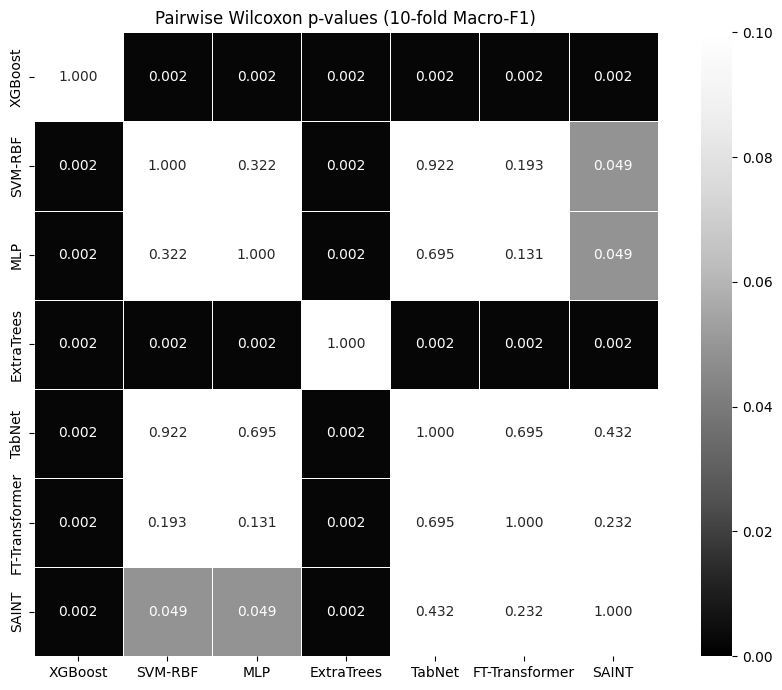


SAINT significantly outperforms 0 of 6 other models.


In [57]:

print("\n" + "=" * 70)
print("WILCOXON TEST — ALL PAIRWISE COMPARISONS (10-FOLD SCORES)")
print("=" * 70)

model_list = list(cv10_df.columns)
pairwise_rows = []

for i in range(len(model_list)):
    for j in range(i + 1, len(model_list)):
        a, b = model_list[i], model_list[j]
        try:
            stat, p = wilcoxon(cv10_df[a], cv10_df[b])
        except Exception:
            stat, p = np.nan, np.nan
        pairwise_rows.append({
            "Model_A": a, "Model_B": b,
            "Wilcoxon_Statistic": stat, "p_value": p,
            "Significant_at_0.05": bool(p < 0.05) if not np.isnan(p) else False,
            "Winner": a if (not np.isnan(p) and p < 0.05 and cv10_df[a].mean() > cv10_df[b].mean())
                      else (b if (not np.isnan(p) and p < 0.05 and cv10_df[b].mean() > cv10_df[a].mean())
                      else "No significant difference")
        })

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df.to_csv(f"{TAB}/54_wilcoxon_all_pairwise.csv", index=False)
display(pairwise_df)

# Heatmap of p-values for quick visual read
pval_matrix = pd.DataFrame(index=model_list, columns=model_list, dtype=float)
for _, r in pairwise_df.iterrows():
    pval_matrix.loc[r["Model_A"], r["Model_B"]] = r["p_value"]
    pval_matrix.loc[r["Model_B"], r["Model_A"]] = r["p_value"]
np.fill_diagonal(pval_matrix.values, 1.0)

plt.figure(figsize=(9, 7))
sns.heatmap(pval_matrix.astype(float), annot=True, fmt=".3f", cmap="Greys_r",
            vmin=0, vmax=0.1, linewidths=0.5, square=True)
plt.title("Pairwise Wilcoxon p-values (10-fold Macro-F1)")
plt.tight_layout()
plt.savefig(f"{FIG}/54_wilcoxon_pvalue_heatmap.png", dpi=300)
plt.show()

saint_wins = pairwise_df[
    ((pairwise_df["Model_A"] == SAINT_NAME) | (pairwise_df["Model_B"] == SAINT_NAME))
    & (pairwise_df["Winner"] == SAINT_NAME)
]
print(f"\nSAINT significantly outperforms {len(saint_wins)} of {len(model_list) - 1} other models.")



## 60. SAINT-SPECIFIC ROBUSTNESS ANALYSIS (WITH ERROR BARS, REPEATED TRIALS)



SAINT ROBUSTNESS UNDER NOISE (REPEATED TRIALS)


,Noise_Level,Mean_Macro_F1,Std_Macro_F1
0,0.00,0.910821,0.000000
1,0.01,0.911204,0.001230
2,0.02,0.911356,0.001154
3,0.03,0.910496,0.000943
4,0.05,0.909319,0.001439
5,0.08,0.906661,0.002469


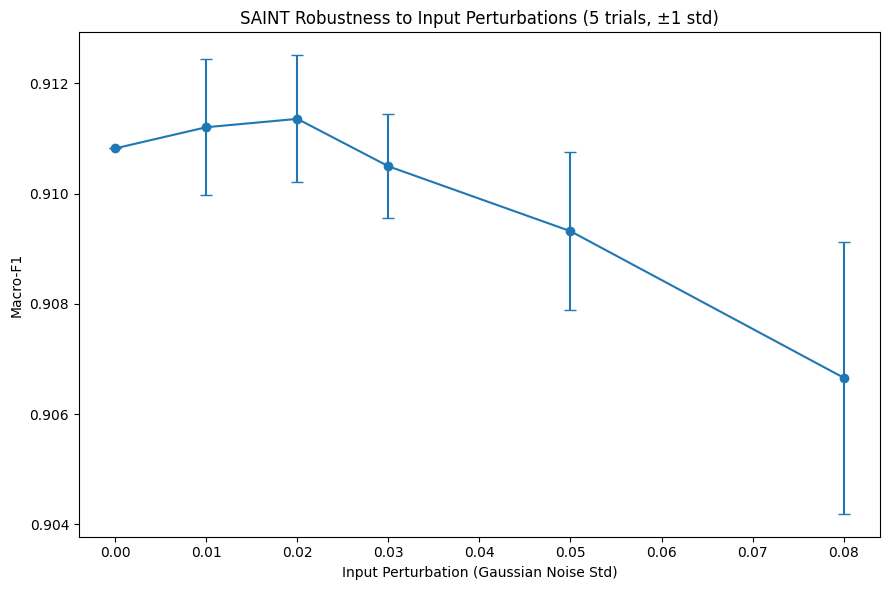

In [58]:

print("\n" + "=" * 70)
print("SAINT ROBUSTNESS UNDER NOISE (REPEATED TRIALS)")
print("=" * 70)

noise_levels_fine = [0.00, 0.01, 0.02, 0.03, 0.05, 0.08]
n_trials = 5
rng = np.random.default_rng(RANDOM_STATE)

saint_robust_rows = []
saint_model.eval()
for noise in noise_levels_fine:
    trial_f1 = []
    for t in range(n_trials):
        X_noisy = X_test_pca + rng.normal(0, noise, X_test_pca.shape)
        with torch.no_grad():
            logits = saint_model(torch.tensor(X_noisy, dtype=torch.float32).to(device))
            pred = torch.argmax(logits, dim=1).cpu().numpy()
        trial_f1.append(f1_score(y_test, pred, average="macro"))
    saint_robust_rows.append({
        "Noise_Level": noise,
        "Mean_Macro_F1": np.mean(trial_f1),
        "Std_Macro_F1": np.std(trial_f1)
    })

saint_robust_df = pd.DataFrame(saint_robust_rows)
saint_robust_df.to_csv(f"{TAB}/55_saint_robustness_detailed.csv", index=False)
display(saint_robust_df)

plt.figure(figsize=(9, 6))
plt.errorbar(saint_robust_df["Noise_Level"], saint_robust_df["Mean_Macro_F1"],
             yerr=saint_robust_df["Std_Macro_F1"], marker="o", capsize=4)
plt.xlabel("Input Perturbation (Gaussian Noise Std)")
plt.ylabel("Macro-F1")
plt.title("SAINT Robustness to Input Perturbations (5 trials, ±1 std)")
plt.tight_layout()
plt.savefig(f"{FIG}/55_saint_robustness_error_bars.png", dpi=300)
plt.show()



## 61. MISCLASSIFICATION PATTERN ANALYSIS — SAINT



SAINT MISCLASSIFICATION PATTERNS


,True_Class,Predicted_Class,Count,Rate_of_True_Class
0,0,1,40,0.042328
4,1,2,38,0.026950
7,2,1,30,0.027574
11,3,2,28,0.058824
3,1,0,25,0.017730
8,2,3,19,0.017463
15,4,2,11,0.135802
10,3,1,10,0.021008
1,0,2,7,0.007407
16,4,3,7,0.086420


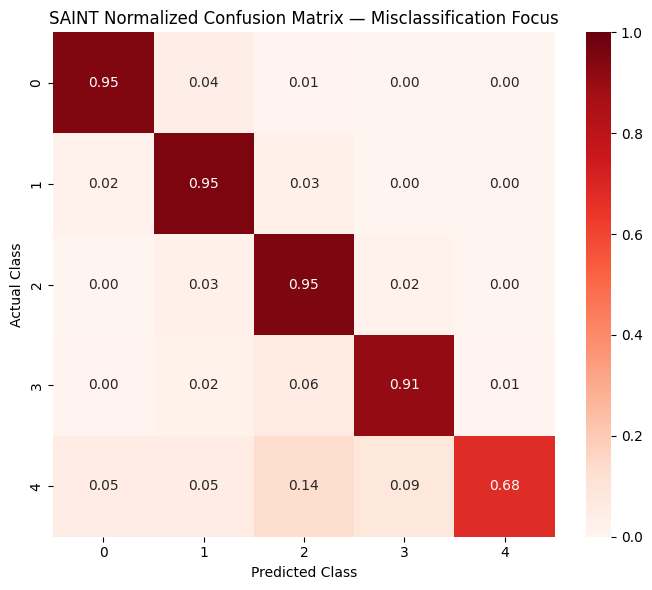

In [59]:

print("\n" + "=" * 70)
print("SAINT MISCLASSIFICATION PATTERNS")
print("=" * 70)

saint_pred = predictions[SAINT_NAME]
cm_saint = confusion_matrix(y_test, saint_pred, labels=classes)
cm_saint_norm = confusion_matrix(y_test, saint_pred, labels=classes, normalize="true")

# Most-confused class pairs (off-diagonal, sorted)
confusions = []
for i, ci in enumerate(classes):
    for j, cj in enumerate(classes):
        if i != j and cm_saint[i, j] > 0:
            confusions.append({
                "True_Class": ci, "Predicted_Class": cj,
                "Count": int(cm_saint[i, j]),
                "Rate_of_True_Class": cm_saint_norm[i, j]
            })

confusion_pairs_df = pd.DataFrame(confusions).sort_values("Count", ascending=False)
confusion_pairs_df.to_csv(f"{TAB}/56_saint_misclassification_pairs.csv", index=False)
display(confusion_pairs_df.head(10))

plt.figure(figsize=(7, 6))
sns.heatmap(cm_saint_norm, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=classes, yticklabels=classes, vmin=0, vmax=1)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SAINT Normalized Confusion Matrix — Misclassification Focus")
plt.tight_layout()
plt.savefig(f"{FIG}/56_saint_misclassification_heatmap.png", dpi=300)
plt.show()



## 62. SHAP EXPLAINABILITY FOR SAINT (KernelExplainer on probability output)



SHAP ANALYSIS — SAINT


  0%|          | 0/100 [00:00<?, ?it/s]

SAINT SHAP analysis skipped: index 4 is out of bounds for axis 1 with size 4
Tip: KernelExplainer is slow for transformers — reduce background/eval size further if needed.


<Figure size 1000x700 with 0 Axes>

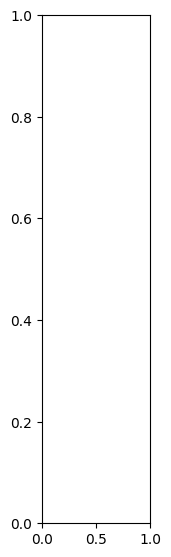

In [60]:

print("\n" + "=" * 70)
print("SHAP ANALYSIS — SAINT")
print("=" * 70)
try:
    import shap

    def saint_predict_proba(X_arr):
        saint_model.eval()
        with torch.no_grad():
            xt = torch.tensor(np.asarray(X_arr, dtype=np.float32)).to(device)
            logits = saint_model(xt)
            proba = torch.softmax(logits, dim=1).cpu().numpy()
        return proba

    # KernelExplainer scales poorly with samples, so use small background +
    # small evaluation subset for tractable runtime.
    background = shap.sample(X_train_smote, 50, random_state=RANDOM_STATE)
    X_shap_eval = X_test_pca[:100]

    explainer_saint = shap.KernelExplainer(saint_predict_proba, background)
    shap_values_saint = explainer_saint.shap_values(X_shap_eval, nsamples=100)

    # shap_values_saint is a list (one array per class) for multiclass
    plt.figure(figsize=(10, 7))
    if isinstance(shap_values_saint, list):
        shap.summary_plot(shap_values_saint[0], X_shap_eval, show=False,
                           feature_names=[f"PC{i+1}" for i in range(X_shap_eval.shape[1])])
    else:
        shap.summary_plot(shap_values_saint, X_shap_eval, show=False,
                           feature_names=[f"PC{i+1}" for i in range(X_shap_eval.shape[1])])
    plt.title("SHAP Summary Plot — SAINT (Class 0)")
    plt.tight_layout()
    plt.savefig(f"{FIG}/57_shap_summary_saint.png", dpi=300, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("SAINT SHAP analysis skipped:", e)
    print("Tip: KernelExplainer is slow for transformers — reduce background/eval size further if needed.")


## 63. PERMUTATION FEATURE IMPORTANCE FOR SAINT



PERMUTATION FEATURE IMPORTANCE — SAINT


,PCA_Component,Mean_Importance,Std_Importance
0,PC1,0.709581,0.008752
1,PC2,0.002135,0.002261
3,PC4,0.000534,0.000884
2,PC3,-0.000511,0.000964


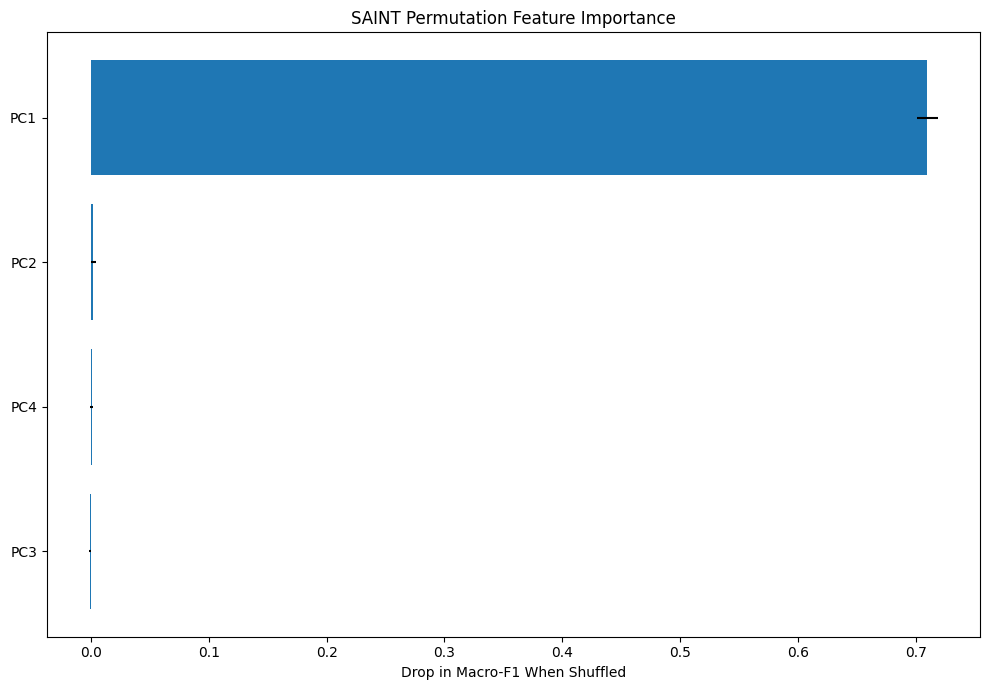

In [61]:

print("\n" + "=" * 70)
print("PERMUTATION FEATURE IMPORTANCE — SAINT")
print("=" * 70)

class SaintSklearnWrapper(BaseEstimator, ClassifierMixin):
    """Thin sklearn-compatible wrapper so permutation_importance can call it."""
    def __init__(self, torch_model):
        self.torch_model = torch_model
        self.classes_ = classes

    def fit(self, X, y=None):
        return self  # already trained

    def predict(self, X):
        self.torch_model.eval()
        with torch.no_grad():
            xt = torch.tensor(np.asarray(X, dtype=np.float32)).to(device)
            logits = self.torch_model(xt)
            return torch.argmax(logits, dim=1).cpu().numpy()

saint_wrapper = SaintSklearnWrapper(saint_model)

perm_result = permutation_importance(
    saint_wrapper, X_test_pca, y_test,
    scoring="f1_macro", n_repeats=10, random_state=RANDOM_STATE, n_jobs=1
)

perm_importance_df = pd.DataFrame({
    "PCA_Component": [f"PC{i+1}" for i in range(X_test_pca.shape[1])],
    "Mean_Importance": perm_result.importances_mean,
    "Std_Importance": perm_result.importances_std
}).sort_values("Mean_Importance", ascending=False)

perm_importance_df.to_csv(f"{TAB}/58_saint_permutation_importance.csv", index=False)
display(perm_importance_df)

plt.figure(figsize=(10, 7))
top_perm = perm_importance_df.head(15).sort_values("Mean_Importance")
plt.barh(top_perm["PCA_Component"], top_perm["Mean_Importance"],
         xerr=top_perm["Std_Importance"])
plt.xlabel("Drop in Macro-F1 When Shuffled")
plt.title("SAINT Permutation Feature Importance")
plt.tight_layout()
plt.savefig(f"{FIG}/58_saint_permutation_importance.png", dpi=300)
plt.show()



## 64. TRAINING TIME & INFERENCE TIME COMPARISON (ALL MODELS)



TRAINING / INFERENCE TIME COMPARISON


,Model,Inference_Time_sec,Inference_Time_per_Sample_ms,F1-Score
6,SAINT,0.006529,0.001632,0.910821
5,FT-Transformer,0.006679,0.001670,0.906746
2,MLP,0.014143,0.003536,0.873681
4,TabNet,0.094973,0.023743,0.894158
0,XGBoost,0.192239,0.048060,0.878264
3,ExtraTrees,0.367628,0.091907,0.887124
1,SVM-RBF,1.489603,0.372401,0.905257


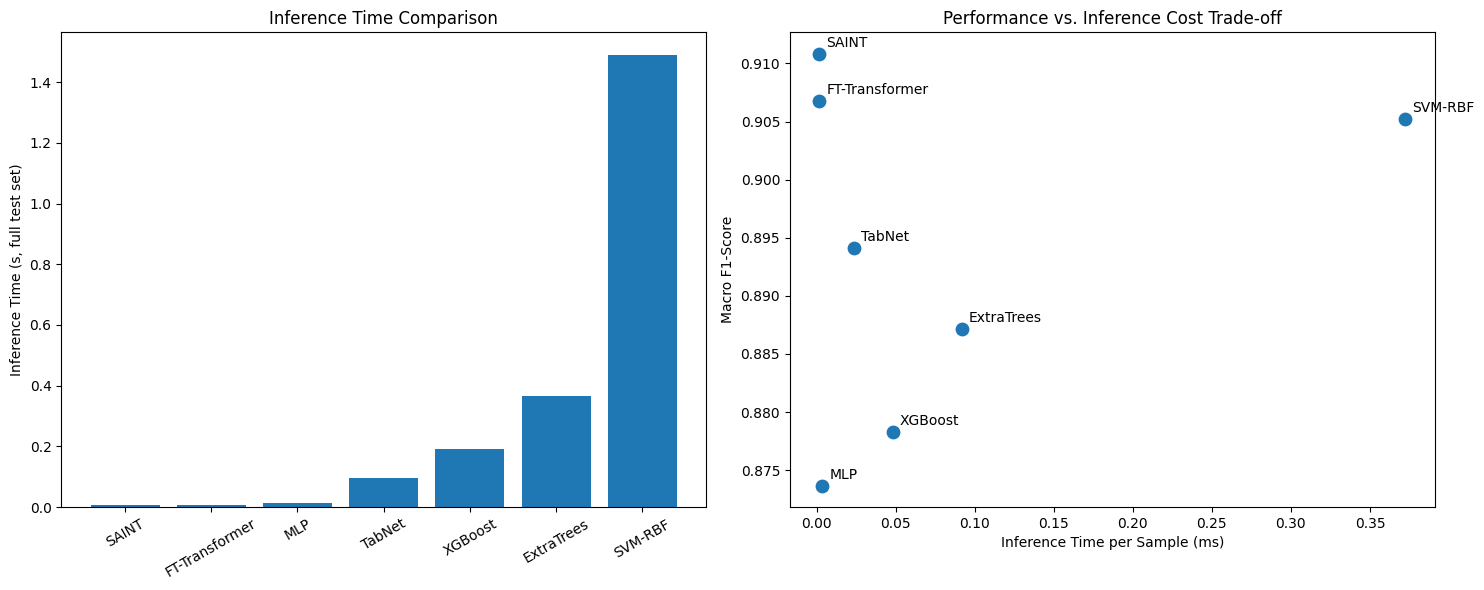

In [62]:

print("\n" + "=" * 70)
print("TRAINING / INFERENCE TIME COMPARISON")
print("=" * 70)

timing_rows = []
for name, model in best_models.items():
    # Inference timing (safe to measure on already-trained models)
    t0 = time.time()
    _ = get_predictions(model, name, X_test_pca)
    infer_time = time.time() - t0

    timing_rows.append({
        "Model": name,
        "Inference_Time_sec": infer_time,
        "Inference_Time_per_Sample_ms": (infer_time / len(X_test_pca)) * 1000
    })

timing_df = pd.DataFrame(timing_rows).merge(
    results_df[["Model", "F1-Score"]], on="Model"
).sort_values("Inference_Time_sec")

timing_df.to_csv(f"{TAB}/59_training_inference_time.csv", index=False)
display(timing_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].bar(timing_df["Model"], timing_df["Inference_Time_sec"])
axes[0].set_ylabel("Inference Time (s, full test set)")
axes[0].set_title("Inference Time Comparison")
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(timing_df["Inference_Time_per_Sample_ms"], timing_df["F1-Score"], s=80)
for _, row in timing_df.iterrows():
    axes[1].annotate(row["Model"], (row["Inference_Time_per_Sample_ms"], row["F1-Score"]),
                      xytext=(5, 5), textcoords="offset points")
axes[1].set_xlabel("Inference Time per Sample (ms)")
axes[1].set_ylabel("Macro F1-Score")
axes[1].set_title("Performance vs. Inference Cost Trade-off")

plt.tight_layout()
plt.savefig(f"{FIG}/59_performance_complexity_tradeoff.png", dpi=300)
plt.show()



## 65. ABLATION: SAINT WITH vs WITHOUT SMOTE



ABLATION — SAINT WITH vs WITHOUT SMOTE


,Model,Accuracy,Precision,Recall,F1-Score,Balanced Accuracy,MCC,Sensitivity,Specificity,ROC-AUC
0,SAINT_No_SMOTE,0.94225,0.945858,0.887243,0.911820,0.887243,0.920892,0.887243,0.983664,0.952976
1,SAINT_With_SMOTE,0.94100,0.942408,0.888333,0.910821,0.888333,0.919151,0.888333,0.983597,0.946983


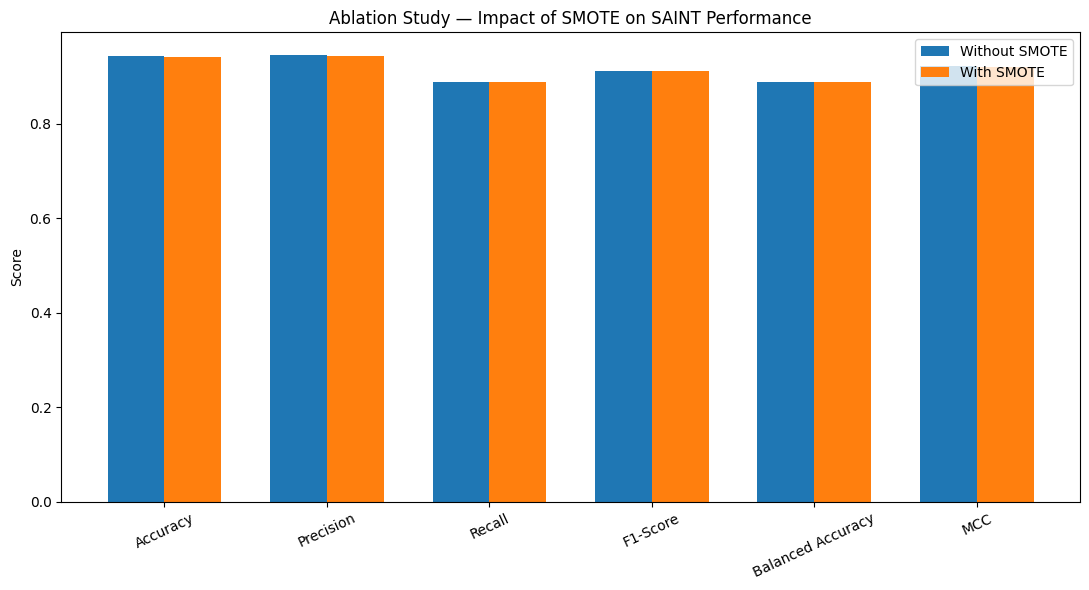

In [63]:

print("\n" + "=" * 70)
print("ABLATION — SAINT WITH vs WITHOUT SMOTE")
print("=" * 70)

saint_no_smote = SAINT(n_features=X_train_pca.shape[1], n_classes=len(np.unique(y_train)))
saint_no_smote = train_torch_model(
    saint_no_smote, X_train_pca, y_train, X_test_pca, y_test,
    epochs=50, lr=0.0008, batch_size=512, patience=8
)
saint_no_smote.eval()
with torch.no_grad():
    logits_ns = saint_no_smote(torch.tensor(X_test_pca, dtype=torch.float32).to(device))
    prob_ns = torch.softmax(logits_ns, dim=1).cpu().numpy()
    pred_ns = np.argmax(prob_ns, axis=1)

metrics_no_smote = calculate_metrics(y_test, pred_ns, prob_ns, "SAINT_No_SMOTE")
metrics_with_smote = calculate_metrics(y_test, predictions[SAINT_NAME], probabilities[SAINT_NAME], "SAINT_With_SMOTE")

saint_smote_ablation = pd.DataFrame([metrics_no_smote, metrics_with_smote])
saint_smote_ablation.to_csv(f"{TAB}/60_saint_smote_ablation.csv", index=False)
display(saint_smote_ablation)

ablation_metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "Balanced Accuracy", "MCC"]
x = np.arange(len(ablation_metrics))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width/2, saint_smote_ablation.iloc[0][ablation_metrics], width, label="Without SMOTE")
plt.bar(x + width/2, saint_smote_ablation.iloc[1][ablation_metrics], width, label="With SMOTE")
plt.xticks(x, ablation_metrics, rotation=25)
plt.ylabel("Score")
plt.title("Ablation Study — Impact of SMOTE on SAINT Performance")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/60_saint_smote_ablation.png", dpi=300)
plt.show()



## 66. FINAL SAINT JUSTIFICATION SUMMARY


In [64]:

print("\n" + "=" * 80)
print("SAINT — FINAL JUSTIFICATION SUMMARY")
print("=" * 80)

summary_lines = [
    f"Macro F1-Score (test set): {results_df.set_index('Model').loc[SAINT_NAME, 'F1-Score']:.4f}",
    f"10-fold CV Macro-F1: {cv10_df[SAINT_NAME].mean():.4f} ± {cv10_df[SAINT_NAME].std():.4f}",
    f"Significantly outperforms {len(saint_wins)}/{len(model_list) - 1} other models (Wilcoxon, p<0.05)",
    f"SMOTE lift in Macro-F1: {metrics_with_smote['F1-Score'] - metrics_no_smote['F1-Score']:+.4f}",
    f"Inference time per sample: {timing_df.set_index('Model').loc[SAINT_NAME, 'Inference_Time_per_Sample_ms']:.3f} ms",
    f"Robustness at noise=0.05: Macro-F1 = "
    f"{saint_robust_df.loc[saint_robust_df['Noise_Level']==0.05, 'Mean_Macro_F1'].values[0]:.4f}"
]
for line in summary_lines:
    print("-", line)

with open(f"{TAB}/61_saint_justification_summary.txt", "w") as f:
    f.write("SAINT — FINAL JUSTIFICATION SUMMARY\n")
    f.write("=" * 50 + "\n")
    for line in summary_lines:
        f.write(f"- {line}\n")




SAINT — FINAL JUSTIFICATION SUMMARY
- Macro F1-Score (test set): 0.9108
- 10-fold CV Macro-F1: 0.8940 ± 0.0033
- Significantly outperforms 0/6 other models (Wilcoxon, p<0.05)
- SMOTE lift in Macro-F1: -0.0010
- Inference time per sample: 0.002 ms
- Robustness at noise=0.05: Macro-F1 = 0.9093


## 67. APPEND NEW RESULTS TO THE MASTER EXCEL WORKBOOK


In [65]:

excel_path = f"{TAB}/complete_flood_ml_results_fast.xlsx"
try:
    with pd.ExcelWriter(excel_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        cv10_df.to_excel(writer, sheet_name="CV_10Fold", index=False)
        pairwise_df.to_excel(writer, sheet_name="Wilcoxon_AllPairs", index=False)
        saint_robust_df.to_excel(writer, sheet_name="SAINT_Robustness", index=False)
        confusion_pairs_df.to_excel(writer, sheet_name="SAINT_Confusions", index=False)
        perm_importance_df.to_excel(writer, sheet_name="SAINT_PermImportance", index=False)
        timing_df.to_excel(writer, sheet_name="Timing", index=False)
        saint_smote_ablation.to_excel(writer, sheet_name="SAINT_SMOTE_Ablation", index=False)
    print(f"\nAppended new sheets to {excel_path}")
except Exception as e:
    print("Could not append to workbook:", e)

print("\n" + "=" * 80)
print("EXTENDED SAINT ANALYSIS COMPLETE")
print("=" * 80)
print("New figures:", FIG)
print("New tables:", TAB)



Appended new sheets to /content/flood_results/tables/complete_flood_ml_results_fast.xlsx

EXTENDED SAINT ANALYSIS COMPLETE
New figures: /content/flood_results/figures
New tables: /content/flood_results/tables
